# 07 Controlled Noise Robustness

## 1. Purpose and Experimental Contract

Notebook 05 established and froze the primary M1–M4 conformal prediction specification for BERT and SpanNER. Notebook 06 subsequently analysed candidate-width effects and the mechanism of M4 without modifying that specification.

This notebook evaluates how the frozen NER, boundary-uncertainty and conformal prediction systems behave when controlled textual corruption is introduced into the same 1,625-sentence CoNLL-2003 validation population.

The analysis is deliberately **paired**. Each corrupted sentence is derived from a fixed clean validation sentence while preserving its token positions and gold labels. Changes in NER performance, boundary uncertainty, conformal coverage and prediction-set size can therefore be measured relative to the corresponding clean sentence.

Because this validation population was previously used during method development, the experiment is interpreted as a **controlled robustness stress test**, not as an independent generalisation evaluation. The official CoNLL-2003 test split remains reserved for Notebook 08.

### Controlled corruption conditions

Four conditions are pre-specified:

| Condition | Eligible-token corruption probability | Role |
|---|---:|---|
| `clean` | 0% | clean reference |
| `low_05` | 5% | mild corruption |
| `medium_10` | 10% | primary noisy condition |
| `high_20` | 20% | severe-noise condition |

The percentages refer to the probability that an **eligible token** is selected for corruption. A selected token then receives a within-token perturbation. The experiment should therefore be interpreted as nested token-level corruption using character/case/punctuation edits rather than as corruption of a fixed percentage of individual characters.

The noisy conditions are nested. Every eligible token receives one deterministic selection value and one deterministic edit. A token active at 5% is consequently also active at 10% and 20%, with the same corrupted form at every applicable severity.

Three perturbation families are used:

- **casing:** lower-case, upper-case or swap-case transformation;
- **spelling:** character substitution, deletion or adjacent transposition;
- **punctuation:** punctuation inserted within the existing token string.

No whitespace is inserted or removed. Consequently, token count, token order, gold BIO labels and gold word-span coordinates remain unchanged.

Tokens are sampled uniformly from the naturally occurring eligible-token population. Corruption is not class-balanced, entity-targeted or boundary-error-targeted.

### Frozen-method rule

All model and conformal quantities remain fixed throughout this notebook:

- BERT and SpanNER are not retrained;
- temperature scalars are not refitted;
- architecture-native candidate universes are unchanged;
- M1–M4 score definitions are unchanged;
- λ values remain those selected in Notebook 05;
- clean conformal thresholds q̂ remain those calibrated in Notebook 05;
- noisy data are never used to recalibrate q̂;
- binary correctness calibrators remain secondary diagnostics and do not enter M1–M4;
- MC Dropout does not enter the robustness conformal scores;
- M5 is not evaluated because it was retained only as a validation-only mechanism diagnostic in Notebook 06.

The primary conformal operating point remains 90% target coverage. The 95% operating point is retained as a secondary analysis and 99% as a high-coverage sensitivity analysis.

Because the frozen q̂ values were calibrated on clean data, conformal results under corruption are interpreted as **empirical coverage retention under distribution shift**, not as a new split-conformal coverage guarantee.

The official CoNLL-2003 test set is not accessed in this notebook.

In [1]:
import hashlib
import json
import os
import random
import string
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


# Reproducibility settings.
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Frozen evaluation population.
VALIDATION_SENTENCES = 1625
VALIDATION_GOLD_SPANS = 3011

PRIMARY_METHODS = (
    "M1",
    "M2",
    "M3",
    "M4",
)

TARGET_COVERAGES = (
    0.90,
    0.95,
    0.99,
)


# Pre-specified corruption ladder.
NOISE_CONDITIONS = {
    "clean": 0.00,
    "low_05": 0.05,
    "medium_10": 0.10,
    "high_20": 0.20,
}

PRIMARY_NOISY_CONDITION = "medium_10"
SECONDARY_NOISY_CONDITION = "high_20"


# Frozen perturbation families.
NOISE_OPERATION_FAMILIES = (
    "casing",
    "spelling",
    "punctuation",
)

SPELLING_OPERATIONS = (
    "substitution",
    "deletion",
    "adjacent_transposition",
)

PUNCTUATION_POOL = (
    ".",
    ",",
    "!",
    "?",
    "'",
    "-",
)


# Paired sentence-level uncertainty intervals used later in the notebook.
BOOTSTRAP_REPLICATES = 500


# No primary method development is permitted in this notebook.
MODELS_RETRAINED = False
TEMPERATURES_REFITTED = False
LAMBDAS_RETUNED = False
CLEAN_QHATS_RECALIBRATED = False

BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4 = False
MC_DROPOUT_USED_IN_ROBUSTNESS_SCORES = False
M5_EVALUATED = False

OFFICIAL_TEST_ACCESSED = False


OUTPUT_ROOT = Path(
    "/kaggle/working/07_controlled_noise_robustness"
)

CONFIG_OUTPUT_DIR = OUTPUT_ROOT / "configuration"
DATA_OUTPUT_DIR = OUTPUT_ROOT / "noise_data"
RESULTS_OUTPUT_DIR = OUTPUT_ROOT / "results"
FIGURE_OUTPUT_DIR = OUTPUT_ROOT / "figures"

for directory in [
    OUTPUT_ROOT,
    CONFIG_OUTPUT_DIR,
    DATA_OUTPUT_DIR,
    RESULTS_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# Freeze the complete robustness protocol before noisy inference is run.
robustness_protocol = {
    "status": "CONTROLLED_NOISE_PROTOCOL_FROZEN",

    "seed": SEED,

    "population": {
        "role": "historical_validation",
        "sentences": VALIDATION_SENTENCES,
        "gold_spans": VALIDATION_GOLD_SPANS,
        "paired_clean_noise_design": True,
    },

    "noise": {
        "conditions": NOISE_CONDITIONS,
        "primary_noisy_condition": PRIMARY_NOISY_CONDITION,
        "secondary_noisy_condition": SECONDARY_NOISY_CONDITION,
        "nested_conditions": True,
        "selection_unit": "eligible_token",
        "operation_families": list(
            NOISE_OPERATION_FAMILIES
        ),
        "spelling_operations": list(
            SPELLING_OPERATIONS
        ),
        "punctuation_pool": list(
            PUNCTUATION_POOL
        ),
        "token_selection": "uniform_over_eligible_tokens",
        "class_balancing": False,
        "entity_targeting": False,
        "boundary_error_targeting": False,
        "token_count_preserved": True,
        "token_order_preserved": True,
        "gold_bio_labels_preserved": True,
        "gold_word_span_coordinates_preserved": True,
    },

    "conformal": {
        "methods": list(
            PRIMARY_METHODS
        ),
        "target_coverages": list(
            TARGET_COVERAGES
        ),
        "primary_target": 0.90,
        "clean_qhats_reused_under_noise": True,
        "noisy_qhat_recalibration": False,
        "interpretation": (
            "empirical coverage retention under distribution shift"
        ),
    },

    "method_freeze": {
        "models_retrained": MODELS_RETRAINED,
        "temperatures_refitted": TEMPERATURES_REFITTED,
        "lambdas_retuned": LAMBDAS_RETUNED,
        "clean_qhats_recalibrated": CLEAN_QHATS_RECALIBRATED,
        "binary_calibrators_used_in_primary_M1_M4": (
            BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4
        ),
        "mc_dropout_used_in_robustness_scores": (
            MC_DROPOUT_USED_IN_ROBUSTNESS_SCORES
        ),
        "M5_evaluated": M5_EVALUATED,
    },

    "bootstrap_replicates": BOOTSTRAP_REPLICATES,

    "official_test_accessed": OFFICIAL_TEST_ACCESSED,
}


protocol_path = (
    CONFIG_OUTPUT_DIR
    / "controlled_noise_protocol.json"
)

with protocol_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        robustness_protocol,
        file,
        indent=2,
    )


protocol_summary_df = pd.DataFrame(
    [
        {
            "Component": "Evaluation population",
            "Setting": "1,625 paired validation sentences",
        },
        {
            "Component": "Corruption conditions",
            "Setting": "Clean / 5% / 10% / 20%",
        },
        {
            "Component": "Corruption selection",
            "Setting": "Uniform over eligible tokens",
        },
        {
            "Component": "Nested severity",
            "Setting": True,
        },
        {
            "Component": "Primary noisy condition",
            "Setting": "10%",
        },
        {
            "Component": "Primary conformal target",
            "Setting": "90%",
        },
        {
            "Component": "Paired bootstrap replicates",
            "Setting": BOOTSTRAP_REPLICATES,
        },
        {
            "Component": "Noisy q-hat recalibration",
            "Setting": False,
        },
    ]
)


print("Table: Notebook 07 Experimental Contract")
display(protocol_summary_df)

print("\nRandom seed:", SEED)
print("Device:", DEVICE)
print("GPU available:", torch.cuda.is_available())
print("Noise conditions:", NOISE_CONDITIONS)
print("Primary methods:", PRIMARY_METHODS)
print("Target coverages:", TARGET_COVERAGES)

print(
    "Models retrained:",
    MODELS_RETRAINED,
)

print(
    "Temperatures refitted:",
    TEMPERATURES_REFITTED,
)

print(
    "Lambdas retuned:",
    LAMBDAS_RETUNED,
)

print(
    "Clean q-hats recalibrated on noise:",
    CLEAN_QHATS_RECALIBRATED,
)

print(
    "Official CoNLL test accessed:",
    OFFICIAL_TEST_ACCESSED,
)

Table: Notebook 07 Experimental Contract


,Component,Setting
0,Evaluation population,"1,625 paired validation sentences"
1,Corruption conditions,Clean / 5% / 10% / 20%
2,Corruption selection,Uniform over eligible tokens
3,Nested severity,True
4,Primary noisy condition,10%
5,Primary conformal target,90%
6,Paired bootstrap replicates,500
7,Noisy q-hat recalibration,False



Random seed: 42
Device: cuda
GPU available: True
Noise conditions: {'clean': 0.0, 'low_05': 0.05, 'medium_10': 0.1, 'high_20': 0.2}
Primary methods: ('M1', 'M2', 'M3', 'M4')
Target coverages: (0.9, 0.95, 0.99)
Models retrained: False
Temperatures refitted: False
Lambdas retuned: False
Clean q-hats recalibrated on noise: False
Official CoNLL test accessed: False


## 2. Frozen Upstream Artefacts and Models

The robustness experiment reuses three authoritative upstream outputs:

1. **Notebook 01: BERT Baseline & Uncertainty**
   - final frozen nine-class BIO model and tokenizer;
   - validation token registry used to verify the evaluation population.

2. **Notebook 02: SpanNER Baseline & Uncertainty**
   - final frozen custom SpanNER model bundle and tokenizer;
   - architecture configuration and five-class span-label mapping.

3. **Notebook 05: Conformal Prediction & M1–M4**
   - frozen temperature scalars;
   - frozen architecture-specific λ configurations;
   - independently calibrated clean conformal thresholds q̂ for the 90%, 95% and 99% operating points.

Notebook 06 is not required here because it performed matched-width and mechanism diagnostics without modifying the primary M1–M4 specification.

All three inputs are located from their saved artefact structure rather than from manually entered model parameters. The custom SpanNER architecture is reconstructed locally and its complete saved state dictionary is loaded before inference. No pretrained model weights are downloaded and no parameter is updated.

The clean validation outputs saved by Notebooks 01 and 02 will later provide a reproduction gate: the newly reconstructed clean inference must agree with the frozen upstream baseline before any noisy result is interpreted.

In [2]:
from transformers import (
    AutoModel,
    AutoModelForTokenClassification,
    AutoTokenizer,
    BertConfig,
)

import torch.nn as nn
import torch.nn.functional as F


KAGGLE_INPUT_ROOT = Path("/kaggle/input")

EXPECTED_BERT_LABELS = {
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-MISC",
    "I-MISC",
}

EXPECTED_SPANNER_LABELS = (
    "NONE",
    "PER",
    "ORG",
    "LOC",
    "MISC",
)


# Locate the final frozen BERT model.
bert_model_candidates = []

for config_path in KAGGLE_INPUT_ROOT.rglob(
    "final_model/config.json"
):
    model_dir = config_path.parent

    has_weights = (
        (model_dir / "model.safetensors").is_file()
        or (model_dir / "pytorch_model.bin").is_file()
    )

    if not has_weights:
        continue

    try:
        with config_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            config_payload = json.load(file)

        saved_labels = {
            str(label)
            for label
            in config_payload.get(
                "id2label",
                {},
            ).values()
        }

    except Exception:
        continue

    if saved_labels == EXPECTED_BERT_LABELS:
        bert_model_candidates.append(
            model_dir
        )


bert_model_candidates = sorted(
    set(bert_model_candidates)
)

if len(bert_model_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one final nine-class BERT model "
        f"directory, found {len(bert_model_candidates)}:\n"
        + "\n".join(
            str(path)
            for path in bert_model_candidates
        )
    )


BERT_MODEL_DIR = (
    bert_model_candidates[0]
)

BERT_ROOT = (
    BERT_MODEL_DIR.parent
)


# Locate the frozen BERT validation token registry.
bert_validation_token_paths = list(
    BERT_ROOT.rglob(
        "validation_token_predictions.csv"
    )
)

if len(bert_validation_token_paths) != 1:
    raise RuntimeError(
        "Expected exactly one BERT validation token registry "
        f"under {BERT_ROOT}, found "
        f"{len(bert_validation_token_paths)}."
    )


BERT_VALIDATION_TOKEN_PATH = (
    bert_validation_token_paths[0]
)

bert_validation_token_df = pd.read_csv(
    BERT_VALIDATION_TOKEN_PATH,
    keep_default_na=False,
)


required_bert_token_columns = {
    "source_index",
    "sentence_id",
    "sentence_index",
    "sentence_length",
    "token_index",
    "token",
    "gold_bio_label",
    "predicted_bio_label",
}

missing_bert_columns = (
    required_bert_token_columns
    - set(
        bert_validation_token_df.columns
    )
)

if missing_bert_columns:
    raise RuntimeError(
        "BERT validation token registry is missing "
        f"required columns: {sorted(missing_bert_columns)}"
    )


if (
    bert_validation_token_df[
        "sentence_index"
    ].nunique()
    != VALIDATION_SENTENCES
):
    raise RuntimeError(
        "BERT validation token registry does not contain "
        f"{VALIDATION_SENTENCES} sentences."
    )


# Locate the frozen SpanNER model bundle.
spanner_bundle_candidates = [
    path
    for path
    in KAGGLE_INPUT_ROOT.rglob(
        "spanner_model.pt"
    )
    if path.parent.name == "final_model"
]

spanner_bundle_candidates = sorted(
    set(spanner_bundle_candidates)
)

if len(spanner_bundle_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one final SpanNER model bundle, "
        f"found {len(spanner_bundle_candidates)}:\n"
        + "\n".join(
            str(path)
            for path in spanner_bundle_candidates
        )
    )


SPANNER_MODEL_BUNDLE_PATH = (
    spanner_bundle_candidates[0]
)

SPANNER_MODEL_DIR = (
    SPANNER_MODEL_BUNDLE_PATH.parent
)

SPANNER_ROOT = (
    SPANNER_MODEL_DIR.parent
)


spanner_bundle = torch.load(
    SPANNER_MODEL_BUNDLE_PATH,
    map_location="cpu",
    weights_only=False,
)


required_spanner_bundle_keys = {
    "model_state_dict",
    "architecture_configuration",
    "training_configuration",
    "span_label_names",
    "bio_label_names",
    "selected_epoch",
    "validation_metrics",
}

missing_spanner_keys = (
    required_spanner_bundle_keys
    - set(spanner_bundle.keys())
)

if missing_spanner_keys:
    raise RuntimeError(
        "SpanNER model bundle is missing required entries: "
        f"{sorted(missing_spanner_keys)}"
    )


spanner_architecture = (
    spanner_bundle[
        "architecture_configuration"
    ]
)

spanner_label_names = tuple(
    str(label)
    for label
    in spanner_bundle[
        "span_label_names"
    ]
)

if (
    spanner_label_names
    != EXPECTED_SPANNER_LABELS
):
    raise RuntimeError(
        "Unexpected SpanNER span-label order: "
        f"{spanner_label_names}"
    )


SPANNER_MAX_WIDTH = int(
    spanner_architecture[
        "maximum_span_width"
    ]
)

if SPANNER_MAX_WIDTH != 4:
    raise RuntimeError(
        "Expected SpanNER maximum width 4, "
        f"got {SPANNER_MAX_WIDTH}."
    )


# Locate the frozen Notebook-05 specification.
conformal_spec_candidates = sorted(
    set(
        KAGGLE_INPUT_ROOT.rglob(
            "final_conformal_specification.json"
        )
    )
)

if len(conformal_spec_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one final Notebook-05 "
        "conformal specification, "
        f"found {len(conformal_spec_candidates)}:\n"
        + "\n".join(
            str(path)
            for path in conformal_spec_candidates
        )
    )


CONFORMAL_SPEC_PATH = (
    conformal_spec_candidates[0]
)

with CONFORMAL_SPEC_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    FROZEN_CONFORMAL_SPEC = json.load(
        file
    )


if (
    FROZEN_CONFORMAL_SPEC.get(
        "status"
    )
    != "M1_M4_CONFORMAL_SPECIFICATION_FROZEN"
):
    raise RuntimeError(
        "The attached Notebook-05 specification "
        "is not the final frozen M1-M4 specification."
    )


if (
    FROZEN_CONFORMAL_SPEC.get(
        "lambda_retuning_permitted_downstream"
    )
    is not False
):
    raise RuntimeError(
        "Notebook-05 specification does not prohibit "
        "downstream lambda retuning."
    )


if (
    FROZEN_CONFORMAL_SPEC.get(
        "official_test_accessed"
    )
    is not False
):
    raise RuntimeError(
        "Unexpected official-test access recorded upstream."
    )


# Temperatures are stored directly in the frozen JSON.
BERT_TEMPERATURE = float(
    FROZEN_CONFORMAL_SPEC[
        "temperatures"
    ]["BERT"]
)

SPANNER_TEMPERATURE = float(
    FROZEN_CONFORMAL_SPEC[
        "temperatures"
    ]["SpanNER"]
)


def _safe_float(
    value,
    default=0.0,
):
    if value is None:
        return float(default)

    return float(value)


def get_frozen_method_parameters(
    model_name,
    method,
):
    """
    Read the final lambda configuration selected in Notebook 05.
    """
    parameters = (
        FROZEN_CONFORMAL_SPEC[
            "lambda_selection"
        ][
            "selected"
        ][model_name][method]
    )

    return {
        "lambda_shared": _safe_float(
            parameters.get(
                "lambda_shared"
            )
        ),
        "lambda_start": _safe_float(
            parameters.get(
                "lambda_start"
            )
        ),
        "lambda_end": _safe_float(
            parameters.get(
                "lambda_end"
            )
        ),
    }


# Use Notebook 05's saved authoritative threshold table.
quantile_candidates = sorted(
    set(
        KAGGLE_INPUT_ROOT.rglob(
            "final_conformal_quantiles.csv"
        )
    )
)

if len(quantile_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one final_conformal_quantiles.csv, "
        f"found {len(quantile_candidates)}:\n"
        + "\n".join(
            str(path)
            for path in quantile_candidates
        )
    )


CONFORMAL_QUANTILE_PATH = (
    quantile_candidates[0]
)

final_conformal_quantiles_df = pd.read_csv(
    CONFORMAL_QUANTILE_PATH
)


required_quantile_columns = {
    "Model",
    "Method",
    "Target Coverage",
    "q_hat",
}

missing_quantile_columns = (
    required_quantile_columns
    - set(
        final_conformal_quantiles_df.columns
    )
)

if missing_quantile_columns:
    raise RuntimeError(
        "Final conformal quantile table is missing "
        f"columns: {sorted(missing_quantile_columns)}"
    )


def get_frozen_q_hat(
    model_name,
    method,
    target_coverage,
):
    """
    Read one clean finite-sample q-hat from the final
    Notebook-05 calibration table.
    """
    rows = final_conformal_quantiles_df.loc[
        (
            final_conformal_quantiles_df[
                "Model"
            ].astype(str)
            == model_name
        )
        & (
            final_conformal_quantiles_df[
                "Method"
            ].astype(str)
            == method
        )
        & np.isclose(
            final_conformal_quantiles_df[
                "Target Coverage"
            ].astype(float),
            float(target_coverage),
        )
    ]

    if len(rows) != 1:
        raise RuntimeError(
            "Expected exactly one frozen q-hat for "
            f"{model_name}, {method}, {target_coverage}; "
            f"found {len(rows)}."
        )

    return float(
        rows.iloc[0]["q_hat"]
    )


# Build a concise frozen-method table.
frozen_parameter_rows = []

for model_name in (
    "BERT",
    "SpanNER",
):
    for method in PRIMARY_METHODS:

        parameters = (
            get_frozen_method_parameters(
                model_name,
                method,
            )
        )

        frozen_parameter_rows.append({
            "Model": model_name,
            "Method": method,
            **parameters,
            "q90": get_frozen_q_hat(
                model_name,
                method,
                0.90,
            ),
            "q95": get_frozen_q_hat(
                model_name,
                method,
                0.95,
            ),
            "q99": get_frozen_q_hat(
                model_name,
                method,
                0.99,
            ),
        })


frozen_parameter_df = pd.DataFrame(
    frozen_parameter_rows
)


print("Frozen BERT model:")
print(BERT_MODEL_DIR)

print("\nFrozen SpanNER bundle:")
print(SPANNER_MODEL_BUNDLE_PATH)

print("\nFrozen Notebook-05 specification:")
print(CONFORMAL_SPEC_PATH)

print("\nFrozen Notebook-05 quantiles:")
print(CONFORMAL_QUANTILE_PATH)

print(
    "\nBERT validation token rows:",
    len(bert_validation_token_df),
)

print(
    "BERT validation sentences:",
    bert_validation_token_df[
        "sentence_index"
    ].nunique(),
)

print(
    "SpanNER maximum width:",
    SPANNER_MAX_WIDTH,
)

print(
    "SpanNER labels:",
    spanner_label_names,
)

print(
    "\nBERT temperature:",
    BERT_TEMPERATURE,
)

print(
    "SpanNER temperature:",
    SPANNER_TEMPERATURE,
)

print(
    "\nTable: Frozen M1-M4 Parameters and Clean Thresholds"
)

display(
    frozen_parameter_df.round(6)
)

print(
    "\nLambda source:",
    "Notebook 05 lambda_selection -> selected",
)

print(
    "q-hat source:",
    "Notebook 05 final_conformal_quantiles.csv",
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "Noisy q-hat recalibration performed:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Frozen BERT model:
/kaggle/input/datasets/umrahzargar/01-bert/01_bert_baseline_and_uncertainty/final_model

Frozen SpanNER bundle:
/kaggle/input/datasets/umrahzargar/02-spanner-new/02_spanner_baseline_and_uncertainty/final_model/spanner_model.pt

Frozen Notebook-05 specification:
/kaggle/input/datasets/umrahzargar/05-conformal-new/05_conformal_prediction_M1_M4/configuration/final_conformal_specification.json

Frozen Notebook-05 quantiles:
/kaggle/input/datasets/umrahzargar/05-conformal-new/05_conformal_prediction_M1_M4/results/final_conformal_quantiles.csv

BERT validation token rows: 26021
BERT validation sentences: 1625
SpanNER maximum width: 4
SpanNER labels: ('NONE', 'PER', 'ORG', 'LOC', 'MISC')

BERT temperature: 1.264385047367806
SpanNER temperature: 1.466518819036767

Table: Frozen M1-M4 Parameters and Clean Thresholds


,Model,Method,lambda_shared,lambda_start,lambda_end,q90,q95,q99
0,BERT,M1,0.00,0.0,0.00,0.117814,0.774801,0.993896
1,BERT,M2,0.01,0.0,0.00,0.117814,0.774801,0.995379
2,BERT,M3,0.00,0.0,0.01,0.117814,0.774801,0.993896
3,BERT,M4,0.00,0.0,0.01,0.117814,0.774801,0.993896
4,SpanNER,M1,0.00,0.0,0.00,0.149860,0.802514,0.998629
5,SpanNER,M2,1.00,0.0,0.00,0.177472,0.820795,1.239742
6,SpanNER,M3,0.00,1.0,1.00,0.177472,0.820795,1.239742
7,SpanNER,M4,0.00,1.0,0.30,0.155677,0.802514,1.011930



Lambda source: Notebook 05 lambda_selection -> selected
q-hat source: Notebook 05 final_conformal_quantiles.csv
Lambda retuning performed: False
Noisy q-hat recalibration performed: False
Official CoNLL test accessed: False


In [3]:
# AUDIT — Notebook 07 official frozen upstream chain
# Verifies Notebook 02 model + Notebook 05 conformal handoff

EXPECTED_SPANNER_SHA256 = (
    "a99b944ce11eb055d30d1f231b2796eb"
    "1a286960c1a459023fb54b72823bd3b5"
)


# 1. Directly fingerprint attached SpanNER model bundle

def audit_file_sha256(path):
    digest = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


observed_spanner_sha = audit_file_sha256(
    SPANNER_MODEL_BUNDLE_PATH
)


# 2. Helper to read one frozen q-hat

def audit_qhat(
    model,
    method,
    target,
):
    rows = final_conformal_quantiles_df.loc[
        (
            final_conformal_quantiles_df[
                "Model"
            ].astype(str).eq(model)
        )
        & (
            final_conformal_quantiles_df[
                "Method"
            ].astype(str).eq(method)
        )
        & np.isclose(
            final_conformal_quantiles_df[
                "Target Coverage"
            ].astype(float),
            target,
        )
    ]

    if len(rows) != 1:
        raise RuntimeError(
            f"Expected exactly one q-hat for "
            f"{model}/{method}/{target}; "
            f"found {len(rows)}."
        )

    return float(
        rows.iloc[0]["q_hat"]
    )


# 3. Ensure Notebook-05 JSON and quantile CSV are same output

notebook05_spec_root = (
    CONFORMAL_SPEC_PATH.parents[1]
)

notebook05_quantile_root = (
    CONFORMAL_QUANTILE_PATH.parents[1]
)

same_notebook05_root = (
    notebook05_spec_root
    == notebook05_quantile_root
)


# 4. Read current q-hats

span_q90 = {
    method: audit_qhat(
        "SpanNER",
        method,
        0.90,
    )
    for method in PRIMARY_METHODS
}

span_q95 = {
    method: audit_qhat(
        "SpanNER",
        method,
        0.95,
    )
    for method in PRIMARY_METHODS
}

span_q99 = {
    method: audit_qhat(
        "SpanNER",
        method,
        0.99,
    )
    for method in PRIMARY_METHODS
}


# 5. Audit checks

checks = {
    "Official 02-spanner-new path": (
        "02-spanner-new"
        in str(
            SPANNER_MODEL_BUNDLE_PATH
        ).lower()
    ),

    "SpanNER model SHA256": (
        observed_spanner_sha
        == EXPECTED_SPANNER_SHA256
    ),

    "SpanNER bundle validation F1": (
        round(
            float(
                spanner_bundle[
                    "validation_metrics"
                ]["f1"]
            ),
            6,
        )
        == 0.957088
    ),

    "Notebook-05 files same root": (
        same_notebook05_root
    ),

    "Notebook-05 frozen status": (
        FROZEN_CONFORMAL_SPEC[
            "status"
        ]
        == "M1_M4_CONFORMAL_SPECIFICATION_FROZEN"
    ),

    "BERT temperature": (
        np.isclose(
            BERT_TEMPERATURE,
            1.264385047,
            atol=5e-7,
        )
    ),

    "NEW SpanNER temperature": (
        np.isclose(
            SPANNER_TEMPERATURE,
            1.466518819,
            atol=5e-7,
        )
    ),

    "Span M1 q90": (
        round(
            span_q90["M1"],
            6,
        )
        == 0.149860
    ),

    "Span M2 q90": (
        round(
            span_q90["M2"],
            6,
        )
        == 0.177472
    ),

    "Span M3 q90": (
        round(
            span_q90["M3"],
            6,
        )
        == 0.177472
    ),

    "Span M4 q90": (
        round(
            span_q90["M4"],
            6,
        )
        == 0.155677
    ),

    "Span M1 q95": (
        round(
            span_q95["M1"],
            6,
        )
        == 0.802514
    ),

    "Span M2 q95": (
        round(
            span_q95["M2"],
            6,
        )
        == 0.820795
    ),

    "Span M3 q95": (
        round(
            span_q95["M3"],
            6,
        )
        == 0.820795
    ),

    "Span M4 q95": (
        round(
            span_q95["M4"],
            6,
        )
        == 0.802514
    ),

    "Span M1 q99": (
        round(
            span_q99["M1"],
            6,
        )
        == 0.998629
    ),

    "Span M2 q99": (
        round(
            span_q99["M2"],
            6,
        )
        == 1.239742
    ),

    "Span M3 q99": (
        round(
            span_q99["M3"],
            6,
        )
        == 1.239742
    ),

    "Span M4 q99": (
        round(
            span_q99["M4"],
            6,
        )
        == 1.011930
    ),

    "Downstream lambda retuning prohibited": (
        FROZEN_CONFORMAL_SPEC[
            "lambda_retuning_permitted_downstream"
        ]
        is False
    ),

    "Official test still untouched": (
        FROZEN_CONFORMAL_SPEC[
            "official_test_accessed"
        ]
        is False
    ),
}


audit_df = pd.DataFrame({
    "Check": list(
        checks.keys()
    ),
    "Pass": list(
        checks.values()
    ),
})

display(audit_df)


if not audit_df["Pass"].all():

    print(
        "\nFAILED CHECKS:"
    )

    display(
        audit_df.loc[
            ~audit_df["Pass"]
        ]
    )

    raise RuntimeError(
        "STALE OR MIXED UPSTREAM ARTEFACTS "
        "DETECTED. Do not continue Notebook 07."
    )


print("=" * 72)

print(
    "PASS: Notebook 07 is connected to "
    "the official frozen upstream chain."
)

print(
    "SpanNER SHA :",
    observed_spanner_sha,
)

print(
    "SpanNER F1  :",
    spanner_bundle[
        "validation_metrics"
    ]["f1"],
)

print(
    "BERT T      :",
    f"{BERT_TEMPERATURE:.9f}",
)

print(
    "SpanNER T   :",
    f"{SPANNER_TEMPERATURE:.9f}",
)

print(
    "Span q90    :",
    {
        k: round(v, 9)
        for k, v
        in span_q90.items()
    },
)

print(
    "Span q95    :",
    {
        k: round(v, 9)
        for k, v
        in span_q95.items()
    },
)

print(
    "Span q99    :",
    {
        k: round(v, 9)
        for k, v
        in span_q99.items()
    },
)

print("=" * 72)

,Check,Pass
0,Official 02-spanner-new path,True
1,SpanNER model SHA256,True
2,SpanNER bundle validation F1,True
3,Notebook-05 files same root,True
4,Notebook-05 frozen status,True
5,BERT temperature,True
6,NEW SpanNER temperature,True
7,Span M1 q90,True
8,Span M2 q90,True
9,Span M3 q90,True


PASS: Notebook 07 is connected to the official frozen upstream chain.
SpanNER SHA : a99b944ce11eb055d30d1f231b2796eb1a286960c1a459023fb54b72823bd3b5
SpanNER F1  : 0.9570879946568709
BERT T      : 1.264385047
SpanNER T   : 1.466518819
Span q90    : {'M1': 0.149860071, 'M2': 0.177472429, 'M3': 0.177472429, 'M4': 0.155676814}
Span q95    : {'M1': 0.80251374, 'M2': 0.820795264, 'M3': 0.820795264, 'M4': 0.80251374}
Span q99    : {'M1': 0.99862928, 'M2': 1.23974219, 'M3': 1.23974219, 'M4': 1.011930314}


### Reconstruct and freeze both models

In [4]:
# BERT can be loaded entirely from the saved Notebook-01 directory.
bert_tokenizer = AutoTokenizer.from_pretrained(
    BERT_MODEL_DIR,
    use_fast=True,
    local_files_only=True,
)

bert_model = (
    AutoModelForTokenClassification
    .from_pretrained(
        BERT_MODEL_DIR,
        local_files_only=True,
    )
    .to(DEVICE)
)

for parameter in bert_model.parameters():
    parameter.requires_grad_(False)

bert_model.eval()

bert_id2label = {
    int(label_id): str(label)
    for label_id, label
    in bert_model.config.id2label.items()
}

if set(bert_id2label.values()) != EXPECTED_BERT_LABELS:
    raise RuntimeError(
        "Reloaded BERT model does not contain the expected BIO labels."
    )


class SpanClassifier(nn.Module):
    """Two-layer classifier used by the frozen SpanNER model."""

    def __init__(
        self,
        input_dim,
        hidden_dim,
        number_of_labels,
        dropout_rate,
    ):
        super().__init__()

        self.linear_1 = nn.Linear(
            input_dim,
            hidden_dim,
        )

        self.dropout = nn.Dropout(
            dropout_rate
        )

        self.linear_2 = nn.Linear(
            hidden_dim,
            number_of_labels,
        )

    def forward(self, span_representations):
        hidden = self.linear_1(
            span_representations
        )

        hidden = F.gelu(hidden)
        hidden = self.dropout(hidden)

        return self.linear_2(hidden)


class BERTSpanNER(nn.Module):
    """Frozen endpoint-based SpanNER architecture."""

    def __init__(
        self,
        bert_config,
        maximum_span_width,
        number_of_width_buckets,
        width_embedding_dim,
        word_length_embedding_dim,
        number_of_labels,
        classifier_dropout,
    ):
        super().__init__()

        # Construct the encoder from the locally saved BERT configuration.
        # The complete fine-tuned SpanNER encoder weights are loaded below.
        self.bert = AutoModel.from_config(
            bert_config
        )

        self.hidden_size = int(
            self.bert.config.hidden_size
        )

        self.tokenised_width_embedding = nn.Embedding(
            num_embeddings=number_of_width_buckets,
            embedding_dim=width_embedding_dim,
        )

        self.word_length_embedding = nn.Embedding(
            num_embeddings=maximum_span_width + 1,
            embedding_dim=word_length_embedding_dim,
            padding_idx=0,
        )

        self.span_representation_dim = (
            2 * self.hidden_size
            + width_embedding_dim
            + word_length_embedding_dim
        )

        self.classifier = SpanClassifier(
            input_dim=self.span_representation_dim,
            hidden_dim=self.span_representation_dim,
            number_of_labels=number_of_labels,
            dropout_rate=classifier_dropout,
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids,
        span_subword_indices,
        span_word_lengths,
        tokenised_width_buckets,
    ):
        bert_outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        sequence_output = (
            bert_outputs.last_hidden_state
        )

        start_indices = (
            span_subword_indices[:, :, 0]
        )

        end_indices = (
            span_subword_indices[:, :, 1]
        )

        hidden_size = int(
            sequence_output.shape[-1]
        )

        start_vectors = torch.gather(
            sequence_output,
            dim=1,
            index=(
                start_indices
                .unsqueeze(-1)
                .expand(
                    -1,
                    -1,
                    hidden_size,
                )
            ),
        )

        end_vectors = torch.gather(
            sequence_output,
            dim=1,
            index=(
                end_indices
                .unsqueeze(-1)
                .expand(
                    -1,
                    -1,
                    hidden_size,
                )
            ),
        )

        width_vectors = (
            self.tokenised_width_embedding(
                tokenised_width_buckets
            )
        )

        word_length_vectors = F.relu(
            self.word_length_embedding(
                span_word_lengths
            )
        )

        span_representations = torch.cat(
            [
                start_vectors,
                end_vectors,
                width_vectors,
                word_length_vectors,
            ],
            dim=-1,
        )

        return self.classifier(
            span_representations
        )


# Notebook 01 and Notebook 02 both use bert-base-cased.
# Its architecture configuration is available locally in the saved
# Notebook-01 model, so no network access is required.
spanner_bert_config = BertConfig.from_pretrained(
    BERT_MODEL_DIR,
    local_files_only=True,
)

if int(spanner_bert_config.hidden_size) != int(
    spanner_architecture["bert_hidden_size"]
):
    raise RuntimeError(
        "BERT backbone dimension disagrees with the saved "
        "SpanNER architecture."
    )

spanner_model = BERTSpanNER(
    bert_config=spanner_bert_config,
    maximum_span_width=int(
        spanner_architecture["maximum_span_width"]
    ),
    number_of_width_buckets=int(
        spanner_architecture["tokenised_width_buckets"]
    ),
    width_embedding_dim=int(
        spanner_architecture[
            "tokenised_width_embedding_dim"
        ]
    ),
    word_length_embedding_dim=int(
        spanner_architecture[
            "word_length_embedding_dim"
        ]
    ),
    number_of_labels=int(
        spanner_architecture[
            "number_of_span_labels"
        ]
    ),
    classifier_dropout=float(
        spanner_architecture["classifier_dropout"]
    ),
).to(DEVICE)

load_result = spanner_model.load_state_dict(
    spanner_bundle["model_state_dict"],
    strict=True,
)

if load_result.missing_keys or load_result.unexpected_keys:
    raise RuntimeError(
        "SpanNER state dictionary did not reload exactly."
    )

for parameter in spanner_model.parameters():
    parameter.requires_grad_(False)

spanner_model.eval()

spanner_tokenizer = AutoTokenizer.from_pretrained(
    SPANNER_MODEL_DIR,
    use_fast=True,
    local_files_only=True,
)


model_status_df = pd.DataFrame([
    {
        "Model": "BERT",
        "Frozen": not any(
            parameter.requires_grad
            for parameter in bert_model.parameters()
        ),
        "Evaluation Mode": not bert_model.training,
        "Fast Tokenizer": bool(
            bert_tokenizer.is_fast
        ),
        "Output Labels": len(
            bert_id2label
        ),
    },
    {
        "Model": "SpanNER",
        "Frozen": not any(
            parameter.requires_grad
            for parameter in spanner_model.parameters()
        ),
        "Evaluation Mode": not spanner_model.training,
        "Fast Tokenizer": bool(
            spanner_tokenizer.is_fast
        ),
        "Output Labels": len(
            spanner_label_names
        ),
    },
])


print("Table: Frozen Model Reconstruction")
display(model_status_df)

print(
    "\nSpanNER selected epoch:",
    int(spanner_bundle["selected_epoch"]),
)

print(
    "SpanNER saved validation F1:",
    float(
        spanner_bundle[
            "validation_metrics"
        ]["f1"]
    ),
)

print(
    "BERT parameters trainable:",
    any(
        parameter.requires_grad
        for parameter in bert_model.parameters()
    ),
)

print(
    "SpanNER parameters trainable:",
    any(
        parameter.requires_grad
        for parameter in spanner_model.parameters()
    ),
)

print(
    "Official CoNLL test accessed:",
    OFFICIAL_TEST_ACCESSED,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Table: Frozen Model Reconstruction


,Model,Frozen,Evaluation Mode,Fast Tokenizer,Output Labels
0,BERT,True,True,True,9
1,SpanNER,True,True,True,5



SpanNER selected epoch: 5
SpanNER saved validation F1: 0.9570879946568709
BERT parameters trainable: False
SpanNER parameters trainable: False
Official CoNLL test accessed: False


## 3. Validation Population and Deterministic Nested Noise Manifest

The controlled-noise experiment is constructed directly from the frozen Notebook-01 validation token registry. No external dataset is reloaded.

The registry contains the original token sequence, gold BIO labels and sentence identities for all 1,625 historical validation sentences. Gold typed spans are reconstructed using the same BIO repair convention used throughout the project: an incompatible `I-X` tag begins a new entity of type `X`.

Three structural quantities are verified before corruption:

- 1,625 validation sentences;
- 26,021 original-word tokens;
- 3,011 gold typed entities.

For SpanNER, entities wider than four original words remain part of the evaluation population but are marked structurally unrepresentable. The expected width≤4 representable population is 2,993 gold entities.

### Token-location audit

Each token is assigned one descriptive location category:

- `entity_internal` — token lies inside a gold entity;
- `boundary_adjacent_context` — non-entity token immediately before or after a gold entity;
- `other_context` — all remaining tokens.

These categories are used only to describe where uniformly sampled corruption happens. They do not influence token selection.

### Deterministic nested corruption

A token is eligible for corruption when it:

- contains at least two characters; and
- contains at least one alphanumeric character.

Every eligible token receives a token-specific pseudorandom generator derived from:

`seed 42 + sentence identity + token position`.

That generator assigns exactly once:

1. a uniform selection value;
2. one corruption family;
3. one exact corrupted token.

The same manifest is then thresholded at 0.05, 0.10 and 0.20. Therefore the noisy populations are nested and the exact edit applied to a token never changes across severity levels.

In [5]:
def bio_tags_to_spans(
    bio_tags,
):
    """Convert BIO labels to typed word spans using the shared repair rule."""
    spans = []

    active_start = None
    active_type = None

    def close_active(end_index):
        nonlocal active_start
        nonlocal active_type

        if active_start is not None:
            spans.append({
                "start": int(active_start),
                "end": int(end_index),
                "entity_type": str(active_type),
            })

        active_start = None
        active_type = None

    for token_index, tag in enumerate(
        bio_tags
    ):
        tag = str(tag)

        if tag == "O":
            close_active(
                token_index - 1
            )
            continue

        if "-" not in tag:
            raise ValueError(
                f"Malformed BIO tag: {tag}"
            )

        prefix, entity_type = (
            tag.split("-", 1)
        )

        if prefix == "B":
            close_active(
                token_index - 1
            )

            active_start = token_index
            active_type = entity_type

        elif prefix == "I":
            # Shared repair rule:
            # an incompatible I-X begins a new X entity.
            if (
                active_start is None
                or active_type != entity_type
            ):
                close_active(
                    token_index - 1
                )

                active_start = token_index
                active_type = entity_type

        else:
            raise ValueError(
                f"Unsupported BIO prefix: {prefix}"
            )

    close_active(
        len(bio_tags) - 1
    )

    return spans


validation_records = []

for sentence_id, group in (
    bert_validation_token_df.groupby(
        "sentence_id",
        sort=False,
    )
):
    group = (
        group.sort_values("token_index")
        .reset_index(drop=True)
    )

    expected_token_indices = np.arange(
        len(group)
    )

    if not np.array_equal(
        group["token_index"].to_numpy(int),
        expected_token_indices,
    ):
        raise RuntimeError(
            f"Non-contiguous token positions in sentence {sentence_id}."
        )

    tokens = (
        group["token"]
        .astype(str)
        .tolist()
    )

    gold_bio_tags = (
        group["gold_bio_label"]
        .astype(str)
        .tolist()
    )

    saved_predicted_bio_tags = (
        group["predicted_bio_label"]
        .astype(str)
        .tolist()
    )

    validation_records.append({
        "sentence_id": int(sentence_id),
        "source_index": int(
            group["source_index"].iloc[0]
        ),
        "sentence_index": int(
            group["sentence_index"].iloc[0]
        ),
        "tokens": tokens,
        "gold_bio_tags": gold_bio_tags,
        "saved_predicted_bio_tags": (
            saved_predicted_bio_tags
        ),
        "gold_spans": bio_tags_to_spans(
            gold_bio_tags
        ),
    })


validation_records = sorted(
    validation_records,
    key=lambda record: record[
        "sentence_index"
    ],
)


observed_gold_entities = sum(
    len(record["gold_spans"])
    for record in validation_records
)


validation_population_audit_df = pd.DataFrame([
    {
        "Audit Item": "Validation sentences",
        "Observed": len(
            validation_records
        ),
        "Expected": VALIDATION_SENTENCES,
        "Passed": (
            len(validation_records)
            == VALIDATION_SENTENCES
        ),
    },
    {
        "Audit Item": "Validation tokens",
        "Observed": len(
            bert_validation_token_df
        ),
        "Expected": 26021,
        "Passed": (
            len(bert_validation_token_df)
            == 26021
        ),
    },
    {
        "Audit Item": "Validation gold entities",
        "Observed": observed_gold_entities,
        "Expected": VALIDATION_GOLD_SPANS,
        "Passed": (
            observed_gold_entities
            == VALIDATION_GOLD_SPANS
        ),
    },
    {
        "Audit Item": "Official CoNLL test accessed",
        "Observed": False,
        "Expected": False,
        "Passed": True,
    },
])


print(
    "Table: Clean Validation Population Audit"
)

display(
    validation_population_audit_df
)


if not validation_population_audit_df[
    "Passed"
].all():
    raise RuntimeError(
        "Clean validation population failed integrity checks."
    )

Table: Clean Validation Population Audit


,Audit Item,Observed,Expected,Passed
0,Validation sentences,1625,1625,True
1,Validation tokens,26021,26021,True
2,Validation gold entities,3011,3011,True
3,Official CoNLL test accessed,False,False,True


### Gold-span and token-location registry

In [6]:
gold_span_rows = []
token_location_rows = []


for record in validation_records:

    sentence_length = len(
        record["tokens"]
    )

    entity_token_mask = np.zeros(
        sentence_length,
        dtype=bool,
    )

    adjacent_context_mask = np.zeros(
        sentence_length,
        dtype=bool,
    )

    for span in record[
        "gold_spans"
    ]:
        start = int(
            span["start"]
        )

        end = int(
            span["end"]
        )

        width = (
            end - start + 1
        )

        entity_token_mask[
            start:end + 1
        ] = True

        if start - 1 >= 0:
            adjacent_context_mask[
                start - 1
            ] = True

        if end + 1 < sentence_length:
            adjacent_context_mask[
                end + 1
            ] = True

        gold_span_rows.append({
            "sentence_id": (
                record["sentence_id"]
            ),
            "sentence_index": (
                record["sentence_index"]
            ),
            "source_index": (
                record["source_index"]
            ),
            "start": start,
            "end": end,
            "entity_type": (
                span["entity_type"]
            ),
            "word_length": int(width),
            "spanner_representable": bool(
                width <= SPANNER_MAX_WIDTH
            ),
        })

    # Entity membership takes precedence over adjacency.
    adjacent_context_mask = (
        adjacent_context_mask
        & ~entity_token_mask
    )

    for token_index, token in enumerate(
        record["tokens"]
    ):

        if entity_token_mask[
            token_index
        ]:
            location_category = (
                "entity_internal"
            )

        elif adjacent_context_mask[
            token_index
        ]:
            location_category = (
                "boundary_adjacent_context"
            )

        else:
            location_category = (
                "other_context"
            )

        token_location_rows.append({
            "sentence_id": (
                record["sentence_id"]
            ),
            "sentence_index": (
                record["sentence_index"]
            ),
            "source_index": (
                record["source_index"]
            ),
            "token_index": int(
                token_index
            ),
            "token": str(token),
            "gold_bio_tag": (
                record["gold_bio_tags"][
                    token_index
                ]
            ),
            "location_category": (
                location_category
            ),
        })


validation_gold_df = pd.DataFrame(
    gold_span_rows
)

validation_token_location_df = pd.DataFrame(
    token_location_rows
)


representable_gold_count = int(
    validation_gold_df[
        "spanner_representable"
    ].sum()
)

if representable_gold_count != 2993:
    raise RuntimeError(
        "Expected 2,993 width≤4 validation gold entities, "
        f"found {representable_gold_count}."
    )


validation_representability_summary_df = pd.DataFrame([
    {
        "Universe": "BERT native",
        "Gold Entities": len(
            validation_gold_df
        ),
        "Representable Entities": len(
            validation_gold_df
        ),
        "Entity Representability (%)": 100.0,
    },
    {
        "Universe": "SpanNER width≤4",
        "Gold Entities": len(
            validation_gold_df
        ),
        "Representable Entities": (
            representable_gold_count
        ),
        "Entity Representability (%)": (
            100.0
            * validation_gold_df[
                "spanner_representable"
            ].mean()
        ),
    },
])


location_inventory_df = (
    validation_token_location_df[
        "location_category"
    ]
    .value_counts()
    .rename_axis(
        "Location Category"
    )
    .reset_index(
        name="Tokens"
    )
)


validation_gold_df.to_csv(
    DATA_OUTPUT_DIR
    / "validation_gold_spans.csv",
    index=False,
)

validation_token_location_df.to_csv(
    DATA_OUTPUT_DIR
    / "validation_token_locations.csv",
    index=False,
)


print(
    "Table: Validation Structural Representability"
)

display(
    validation_representability_summary_df.round(6)
)

print(
    "\nTable: Validation Token Location Inventory"
)

display(
    location_inventory_df
)

Table: Validation Structural Representability


,Universe,Gold Entities,Representable Entities,Entity Representability (%)
0,BERT native,3011,3011,100.000000
1,SpanNER width≤4,3011,2993,99.402192



Table: Validation Token Location Inventory


,Location Category,Tokens
0,other_context,17029
1,boundary_adjacent_context,4561
2,entity_internal,4431


### 3.1 Frozen Nested Noise Manifest

The corruption manifest is generated independently of model outcomes.

Eligibility is based only on the clean token string. For every eligible token, a deterministic token-specific random generator assigns one selection value and one edit.

The corruption families are sampled uniformly from casing, spelling and punctuation. Spelling noise then samples from substitution, deletion and adjacent transposition. If a sampled transformation happens to leave the token unchanged, a case transformation is used as a deterministic fallback.

No corruption creates or removes an original-word token slot.

### Build the exact deterministic manifest

In [7]:
ALPHANUMERIC_POOL = (
    string.ascii_letters
    + string.digits
)


def token_is_noise_eligible(
    token,
):
    """Eligible tokens are non-trivial and contain alphanumeric content."""
    token = str(token)

    return (
        len(token) >= 2
        and any(
            character.isalnum()
            for character in token
        )
    )


def deterministic_token_seed(
    sentence_id,
    token_index,
):
    """Create the fixed token-specific seed used by the old robustness design."""
    payload = (
        f"{SEED}|noise_manifest|"
        f"{sentence_id}|{token_index}"
    ).encode("utf-8")

    digest = hashlib.sha256(
        payload
    ).hexdigest()

    return (
        int(digest[:16], 16)
        % (2**32)
    )


def apply_casing_noise(
    token,
):
    token = str(token)

    if token.islower():
        corrupted = token.upper()

    elif token.isupper():
        corrupted = token.lower()

    else:
        corrupted = token.swapcase()

    if corrupted == token:
        corrupted = (
            token.lower()
            if token != token.lower()
            else token.upper()
        )

    return corrupted


def apply_spelling_noise(
    token,
    rng,
):
    token = str(token)

    available_operations = [
        "substitution",
    ]

    if len(token) >= 2:
        available_operations.extend([
            "deletion",
            "adjacent_transposition",
        ])

    operation = str(
        rng.choice(
            available_operations
        )
    )

    if operation == "substitution":

        positions = [
            index
            for index, character
            in enumerate(token)
            if character.isalnum()
        ]

        if not positions:
            positions = list(
                range(len(token))
            )

        position = int(
            rng.choice(positions)
        )

        current_character = (
            token[position]
        )

        alternatives = [
            character
            for character
            in ALPHANUMERIC_POOL
            if character
            != current_character
        ]

        replacement = str(
            rng.choice(
                alternatives
            )
        )

        corrupted = (
            token[:position]
            + replacement
            + token[position + 1:]
        )

    elif operation == "deletion":

        position = int(
            rng.integers(
                0,
                len(token),
            )
        )

        corrupted = (
            token[:position]
            + token[position + 1:]
        )

        if corrupted == "":
            corrupted = (
                apply_casing_noise(
                    token
                )
            )

    else:
        position = int(
            rng.integers(
                0,
                len(token) - 1,
            )
        )

        characters = list(token)

        (
            characters[position],
            characters[position + 1],
        ) = (
            characters[position + 1],
            characters[position],
        )

        corrupted = "".join(
            characters
        )

        if corrupted == token:
            corrupted = (
                apply_casing_noise(
                    token
                )
            )

    return (
        corrupted,
        operation,
    )


def apply_punctuation_noise(
    token,
    rng,
):
    token = str(token)

    punctuation = str(
        rng.choice(
            PUNCTUATION_POOL
        )
    )

    placement = str(
        rng.choice([
            "prefix",
            "suffix",
        ])
    )

    if placement == "prefix":
        corrupted = (
            punctuation + token
        )
    else:
        corrupted = (
            token + punctuation
        )

    return (
        corrupted,
        placement,
    )


noise_manifest_rows = []


for row in (
    validation_token_location_df
    .itertuples(index=False)
):

    token = str(
        row.token
    )

    eligible = (
        token_is_noise_eligible(
            token
        )
    )

    if eligible:

        rng = np.random.default_rng(
            deterministic_token_seed(
                row.sentence_id,
                row.token_index,
            )
        )

        selection_value = float(
            rng.random()
        )

        operation_family = str(
            rng.choice(
                NOISE_OPERATION_FAMILIES
            )
        )

        if operation_family == "casing":

            corrupted_token = (
                apply_casing_noise(
                    token
                )
            )

            operation_detail = (
                "case_transform"
            )

        elif operation_family == "spelling":

            (
                corrupted_token,
                operation_detail,
            ) = apply_spelling_noise(
                token,
                rng,
            )

        else:

            (
                corrupted_token,
                operation_detail,
            ) = apply_punctuation_noise(
                token,
                rng,
            )

        # Guarantee that every selected eligible token
        # actually differs from its clean form.
        if corrupted_token == token:

            corrupted_token = (
                apply_casing_noise(
                    token
                )
            )

            operation_family = (
                "casing"
            )

            operation_detail = (
                "fallback_case_transform"
            )

    else:

        selection_value = np.nan
        operation_family = (
            "ineligible"
        )
        operation_detail = "none"
        corrupted_token = token


    noise_manifest_rows.append({
        "sentence_id": int(
            row.sentence_id
        ),
        "sentence_index": int(
            row.sentence_index
        ),
        "token_index": int(
            row.token_index
        ),
        "clean_token": token,
        "gold_bio_tag": str(
            row.gold_bio_tag
        ),
        "location_category": str(
            row.location_category
        ),
        "eligible": bool(
            eligible
        ),
        "selection_value": (
            selection_value
        ),
        "operation_family": (
            operation_family
        ),
        "operation_detail": (
            operation_detail
        ),
        "corrupted_token": str(
            corrupted_token
        ),
    })


noise_manifest_df = pd.DataFrame(
    noise_manifest_rows
)


noise_manifest_path = (
    DATA_OUTPUT_DIR
    / "frozen_nested_noise_manifest.csv"
)

noise_manifest_df.to_csv(
    noise_manifest_path,
    index=False,
)


eligible_token_count = int(
    noise_manifest_df[
        "eligible"
    ].sum()
)


noise_manifest_summary_df = pd.DataFrame([
    {
        "Metric": "Total tokens",
        "Value": len(
            noise_manifest_df
        ),
    },
    {
        "Metric": "Eligible tokens",
        "Value": (
            eligible_token_count
        ),
    },
    {
        "Metric": "Eligible-token proportion",
        "Value": float(
            noise_manifest_df[
                "eligible"
            ].mean()
        ),
    },
    {
        "Metric": "Manifest seed",
        "Value": SEED,
    },
])


print(
    "Table: Frozen Noise Manifest Summary"
)

display(
    noise_manifest_summary_df
)


if eligible_token_count != 21462:
    raise RuntimeError(
        "The clean token registry did not reproduce the "
        "expected 21,462 eligible tokens."
    )


print(
    "\nManifest saved:",
    noise_manifest_path,
)

Table: Frozen Noise Manifest Summary


,Metric,Value
0,Total tokens,26021.000000
1,Eligible tokens,21462.000000
2,Eligible-token proportion,0.824795
3,Manifest seed,42.000000



Manifest saved: /kaggle/working/07_controlled_noise_robustness/noise_data/frozen_nested_noise_manifest.csv


### 3.2 Materialise and Audit the Four Paired Conditions

The clean and three corrupted conditions share exactly the same sentence identities, token positions, gold BIO labels and gold typed-span coordinates.

A token is corrupted in condition `p` only when its frozen manifest selection value is below `p`.

Because the same selection value is reused, the active corruption sets must satisfy:

5% ⊆ 10% ⊆ 20%`.

The realised percentages need not equal the nominal values exactly because they arise from deterministic Bernoulli-style thresholding over 21,462 eligible tokens.

In [8]:
def materialise_noise_condition(
    records,
    condition_name,
    corruption_probability,
):
    """Apply one threshold to the already-frozen noise manifest."""

    manifest_lookup = (
        noise_manifest_df.set_index(
            [
                "sentence_id",
                "token_index",
            ]
        )
    )

    condition_records_local = []
    audit_rows = []

    for record in records:

        noisy_tokens = []
        changed_positions = []

        for token_index, clean_token in enumerate(
            record["tokens"]
        ):

            manifest_row = (
                manifest_lookup.loc[
                    (
                        record["sentence_id"],
                        token_index,
                    )
                ]
            )

            active = bool(
                manifest_row["eligible"]
                and float(
                    manifest_row[
                        "selection_value"
                    ]
                )
                < float(
                    corruption_probability
                )
            )

            if active:

                observed_token = str(
                    manifest_row[
                        "corrupted_token"
                    ]
                )

                changed_positions.append(
                    token_index
                )

            else:

                observed_token = str(
                    clean_token
                )

            noisy_tokens.append(
                observed_token
            )

            audit_rows.append({
                "condition": (
                    condition_name
                ),
                "sentence_id": (
                    record["sentence_id"]
                ),
                "sentence_index": (
                    record["sentence_index"]
                ),
                "token_index": int(
                    token_index
                ),
                "clean_token": str(
                    clean_token
                ),
                "observed_token": (
                    observed_token
                ),
                "changed": bool(
                    active
                ),
                "location_category": str(
                    manifest_row[
                        "location_category"
                    ]
                ),
                "operation_family": (
                    str(
                        manifest_row[
                            "operation_family"
                        ]
                    )
                    if active
                    else "none"
                ),
            })

        if len(noisy_tokens) != len(
            record["tokens"]
        ):
            raise RuntimeError(
                "Noise changed the number of original tokens."
            )

        condition_records_local.append({
            **record,
            "condition": (
                condition_name
            ),
            "clean_tokens": list(
                record["tokens"]
            ),
            "tokens": noisy_tokens,
            "changed_token_positions": (
                changed_positions
            ),
        })

    return (
        condition_records_local,
        pd.DataFrame(
            audit_rows
        ),
    )


condition_records = {}
condition_token_audit_frames = []


for (
    condition_name,
    corruption_probability,
) in NOISE_CONDITIONS.items():

    (
        current_records,
        current_audit_df,
    ) = materialise_noise_condition(
        records=validation_records,
        condition_name=condition_name,
        corruption_probability=(
            corruption_probability
        ),
    )

    condition_records[
        condition_name
    ] = current_records

    condition_token_audit_frames.append(
        current_audit_df
    )


condition_token_audit_df = pd.concat(
    condition_token_audit_frames,
    ignore_index=True,
)


noise_realisation_rows = []

total_token_count = len(
    noise_manifest_df
)


for condition_name in NOISE_CONDITIONS:

    group = (
        condition_token_audit_df.loc[
            condition_token_audit_df[
                "condition"
            ].eq(condition_name)
        ]
    )

    changed_tokens = int(
        group["changed"].sum()
    )

    noise_realisation_rows.append({
        "Condition": (
            condition_name
        ),
        "Nominal Rate": (
            NOISE_CONDITIONS[
                condition_name
            ]
        ),
        "Changed Tokens": (
            changed_tokens
        ),
        "Rate over Eligible Tokens": (
            changed_tokens
            / eligible_token_count
        ),
        "Rate over All Tokens": (
            changed_tokens
            / total_token_count
        ),
        "Token Count Preserved": True,
        "Gold BIO Sequence Preserved": True,
    })


noise_realisation_summary_df = pd.DataFrame(
    noise_realisation_rows
)


noise_location_summary_df = (
    condition_token_audit_df.loc[
        condition_token_audit_df[
            "changed"
        ]
    ]
    .groupby(
        [
            "condition",
            "location_category",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "Changed Tokens"
        }
    )
)


def changed_identity_set(
    condition_name,
):
    rows = (
        condition_token_audit_df.loc[
            (
                condition_token_audit_df[
                    "condition"
                ].eq(condition_name)
            )
            & (
                condition_token_audit_df[
                    "changed"
                ]
            ),
            [
                "sentence_id",
                "token_index",
            ],
        ]
    )

    return set(
        map(
            tuple,
            rows.to_numpy(),
        )
    )


low_changed = changed_identity_set(
    "low_05"
)

medium_changed = changed_identity_set(
    "medium_10"
)

high_changed = changed_identity_set(
    "high_20"
)


nested_noise_passed = (
    low_changed.issubset(
        medium_changed
    )
    and medium_changed.issubset(
        high_changed
    )
)


print(
    "Table: Controlled Noise Realisation Summary"
)

display(
    noise_realisation_summary_df.round(6)
)

print(
    "\nTable: Changed-Token Location Summary"
)

display(
    noise_location_summary_df
)

print(
    "\nNested 5% → 10% → 20% corruption:",
    nested_noise_passed,
)


if not nested_noise_passed:
    raise RuntimeError(
        "Noise conditions are not nested."
    )


noise_realisation_summary_df.to_csv(
    DATA_OUTPUT_DIR
    / "controlled_noise_realisation_summary.csv",
    index=False,
)

noise_location_summary_df.to_csv(
    DATA_OUTPUT_DIR
    / "controlled_noise_location_summary.csv",
    index=False,
)

condition_token_audit_df.to_csv(
    DATA_OUTPUT_DIR
    / "controlled_noise_token_audit.csv",
    index=False,
)


print(
    "\nMaterialised conditions:",
    list(condition_records.keys()),
)

print(
    "Models retrained:",
    False,
)

print(
    "Noisy q-hat recalibration:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Controlled Noise Realisation Summary


,Condition,Nominal Rate,Changed Tokens,Rate over Eligible Tokens,Rate over All Tokens,Token Count Preserved,Gold BIO Sequence Preserved
0,clean,0.00,0,0.000000,0.000000,True,True
1,low_05,0.05,1117,0.052045,0.042927,True,True
2,medium_10,0.10,2224,0.103625,0.085469,True,True
3,high_20,0.20,4419,0.205899,0.169824,True,True



Table: Changed-Token Location Summary


,condition,location_category,Changed Tokens
0,high_20,boundary_adjacent_context,590
1,high_20,entity_internal,923
2,high_20,other_context,2906
3,low_05,boundary_adjacent_context,159
4,low_05,entity_internal,236
5,low_05,other_context,722
6,medium_10,boundary_adjacent_context,311
7,medium_10,entity_internal,474
8,medium_10,other_context,1439



Nested 5% → 10% → 20% corruption: True

Materialised conditions: ['clean', 'low_05', 'medium_10', 'high_20']
Models retrained: False
Noisy q-hat recalibration: False
Official CoNLL test accessed: False


## 4. Frozen Inference and Clean Reproduction Gate

Before evaluating any corrupted condition, both frozen architectures are rerun on the unchanged validation text.

This serves two purposes:

1. verify that the final Notebook-01 and Notebook-02 models have been reconstructed correctly; and
2. verify that the architecture-native confidence, boundary-uncertainty and conformal candidate constructions remain identical to the frozen upstream methodology.

### BERT inference

Deterministic BIO predictions are obtained from the unscaled model-logit argmax at the first subword position of each original token.

Temperature scaling is applied only when constructing probabilities for uncertainty and conformal scoring.

For a typed candidate $$(s,e,t)$$:

- confidence is the geometric mean of $$P(B-t)$$ at the start and $$P(I-t)$$ across continuation tokens;
- start uncertainty is $$P(I-t at s) / [P(B-t at s) + P(I-t at s) + ε]$$;
- end uncertainty is $$P(I-t at e+1)$$, or zero at sentence end.

BERT retains its native universe of all contiguous original-word spans × four entity types.

### SpanNER inference

SpanNER enumerates every original-word span of width ≤4.

Deterministic NER decoding uses the frozen greedy non-overlap decoder applied to the unscaled five-class probabilities. Temperature-scaled probabilities are used separately for conformal candidate confidence.

For each typed candidate, start and end uncertainty compare its confidence against the strongest same-type candidate with the alternative start or end boundary respectively. Missing competitors contribute uncertainty zero.

### Clean gate

The notebook proceeds to noisy inference only if:

- BERT token predictions exactly reproduce the saved Notebook-01 registry;
- BERT strict typed-span F1 reproduces the saved clean baseline;
- SpanNER strict typed-span F1 reproduces the final Notebook-02 checkpoint;
- BERT recovers all 3,011 gold typed candidates;
- SpanNER recovers all 2,993 structurally representable gold candidates;
- the expected architecture-native candidate populations are recovered.

No noisy result is accepted if this gate fails.

In [9]:
import gc
import time

from torch.utils.data import DataLoader


MAX_SEQUENCE_LENGTH = 256
BERT_BATCH_SIZE = 32
SPANNER_BATCH_SIZE = 16

METHODS = list(
    PRIMARY_METHODS
)

ENTITY_TYPES = [
    "PER",
    "ORG",
    "LOC",
    "MISC",
]

EPSILON = 1e-12


spanner_label2id = {
    label: index
    for index, label
    in enumerate(
        spanner_label_names
    )
}

spanner_id2label = {
    index: label
    for label, index
    in spanner_label2id.items()
}


def stable_softmax(
    logits,
    axis=-1,
):
    """Numerically stable NumPy softmax."""
    logits = np.asarray(
        logits,
        dtype=np.float64,
    )

    shifted = (
        logits
        - np.max(
            logits,
            axis=axis,
            keepdims=True,
        )
    )

    exponentials = np.exp(
        shifted
    )

    return (
        exponentials
        / exponentials.sum(
            axis=axis,
            keepdims=True,
        )
    )


def add_normalized_boundary_ranks(
    candidate_df,
):
    """Add candidate-local normalized start/end rank penalties."""
    result = (
        candidate_df
        .reset_index(drop=True)
        .copy()
    )

    start_group_columns = [
        "sentence_id",
        "end",
        "entity_type",
    ]

    end_group_columns = [
        "sentence_id",
        "start",
        "entity_type",
    ]

    start_rank = (
        result.groupby(
            start_group_columns,
            sort=False,
        )["base_confidence"]
        .rank(
            method="min",
            ascending=False,
        )
    )

    start_count = (
        result.groupby(
            start_group_columns,
            sort=False,
        )["base_confidence"]
        .transform("size")
    )

    end_rank = (
        result.groupby(
            end_group_columns,
            sort=False,
        )["base_confidence"]
        .rank(
            method="min",
            ascending=False,
        )
    )

    end_count = (
        result.groupby(
            end_group_columns,
            sort=False,
        )["base_confidence"]
        .transform("size")
    )

    result[
        "start_rank_penalty"
    ] = np.where(
        start_count > 1,
        (
            start_rank - 1.0
        )
        / (
            start_count - 1.0
        ),
        0.0,
    )

    result[
        "end_rank_penalty"
    ] = np.where(
        end_count > 1,
        (
            end_rank - 1.0
        )
        / (
            end_count - 1.0
        ),
        0.0,
    )

    return result


def strongest_excluding_self(
    candidate_df,
    group_columns,
):
    """Return the strongest alternative candidate within each group."""
    working = (
        candidate_df
        .reset_index(drop=True)
    )

    confidence = working[
        "base_confidence"
    ].to_numpy(float)

    competitor = np.full(
        len(working),
        np.nan,
        dtype=float,
    )

    group_indices = (
        working.groupby(
            group_columns,
            sort=False,
        ).indices
    )

    for indices in group_indices.values():

        indices = np.asarray(
            indices,
            dtype=int,
        )

        if len(indices) <= 1:
            continue

        values = confidence[
            indices
        ]

        order = np.argsort(
            -values,
            kind="stable",
        )

        strongest_local = int(
            order[0]
        )

        second_local = int(
            order[1]
        )

        strongest_value = float(
            values[
                strongest_local
            ]
        )

        second_value = float(
            values[
                second_local
            ]
        )

        competitor[
            indices
        ] = strongest_value

        competitor[
            indices[
                strongest_local
            ]
        ] = second_value

    return competitor


def add_frozen_method_scores(
    candidate_df,
    model,
):
    """Apply the frozen Notebook-05 M1-M4 equations."""
    result = (
        candidate_df
        .reset_index(drop=True)
        .copy()
    )

    base = result[
        "base_nonconformity"
    ].to_numpy(float)

    rs = result[
        "start_rank_penalty"
    ].to_numpy(float)

    re = result[
        "end_rank_penalty"
    ].to_numpy(float)

    us = result[
        "start_uncertainty"
    ].to_numpy(float)

    ue = result[
        "end_uncertainty"
    ].to_numpy(float)

    for method in METHODS:

        parameters = (
            get_frozen_method_parameters(
                model,
                method,
            )
        )

        lambda_shared = (
            parameters[
                "lambda_shared"
            ]
        )

        lambda_start = (
            parameters[
                "lambda_start"
            ]
        )

        lambda_end = (
            parameters[
                "lambda_end"
            ]
        )

        if method == "M1":

            score = base.copy()

        elif method == "M2":

            score = (
                base
                + lambda_shared
                * (
                    rs + re
                )
                / 2.0
            )

        elif method == "M3":

            score = (
                base
                + (
                    lambda_start * rs
                    + lambda_end * re
                )
                / 2.0
            )

        elif method == "M4":

            score = (
                base
                + (
                    lambda_start
                    * (1.0 - us)
                    * rs
                    + lambda_end
                    * (1.0 - ue)
                    * re
                )
                / 2.0
            )

        else:
            raise ValueError(
                f"Unsupported method: {method}"
            )

        result[
            f"score_{method}"
        ] = score

    return result


def span_identity_set(
    spans,
):
    """Convert typed spans into strict identity tuples."""
    return {
        (
            int(span["start"]),
            int(span["end"]),
            str(
                span["entity_type"]
            ),
        )
        for span in spans
    }


def compute_strict_span_metrics(
    gold_spans_by_sentence,
    predicted_spans_by_sentence,
):
    """Compute strict micro typed-span precision, recall and F1."""
    true_positive = 0
    false_positive = 0
    false_negative = 0

    sentence_ids = sorted(
        set(
            gold_spans_by_sentence
        )
        | set(
            predicted_spans_by_sentence
        )
    )

    for sentence_id in sentence_ids:

        gold_set = span_identity_set(
            gold_spans_by_sentence.get(
                sentence_id,
                [],
            )
        )

        predicted_set = span_identity_set(
            predicted_spans_by_sentence.get(
                sentence_id,
                [],
            )
        )

        true_positive += len(
            gold_set & predicted_set
        )

        false_positive += len(
            predicted_set - gold_set
        )

        false_negative += len(
            gold_set - predicted_set
        )

    precision = (
        true_positive
        / (
            true_positive
            + false_positive
        )
        if (
            true_positive
            + false_positive
        )
        else 0.0
    )

    recall = (
        true_positive
        / (
            true_positive
            + false_negative
        )
        if (
            true_positive
            + false_negative
        )
        else 0.0
    )

    f1 = (
        2.0
        * precision
        * recall
        / (
            precision + recall
        )
        if (
            precision + recall
        )
        else 0.0
    )

    return {
        "TP": int(
            true_positive
        ),
        "FP": int(
            false_positive
        ),
        "FN": int(
            false_negative
        ),
        "Precision": float(
            precision
        ),
        "Recall": float(
            recall
        ),
        "F1": float(
            f1
        ),
    }


GOLD_SPANS_BY_SENTENCE = {
    record[
        "sentence_id"
    ]: record[
        "gold_spans"
    ]
    for record
    in validation_records
}


print(
    "Frozen scoring utilities defined."
)

print(
    "Methods:",
    METHODS,
)

print(
    "Entity types:",
    ENTITY_TYPES,
)

print(
    "Maximum sequence length:",
    MAX_SEQUENCE_LENGTH,
)

Frozen scoring utilities defined.
Methods: ['M1', 'M2', 'M3', 'M4']
Entity types: ['PER', 'ORG', 'LOC', 'MISC']
Maximum sequence length: 256


### Frozen BERT inference and candidate construction

In [10]:
def run_bert_token_inference(
    records,
):
    """Run frozen BERT BIO inference on one text condition."""
    token_rows = []
    predicted_spans_by_sentence = {}

    bert_model.eval()

    for batch_start in range(
        0,
        len(records),
        BERT_BATCH_SIZE,
    ):

        batch_records = records[
            batch_start:
            batch_start
            + BERT_BATCH_SIZE
        ]

        batch_tokens = [
            record["tokens"]
            for record
            in batch_records
        ]

        encoded = bert_tokenizer(
            batch_tokens,
            is_split_into_words=True,
            add_special_tokens=True,
            truncation=False,
            padding=True,
            return_tensors="pt",
        )

        true_lengths = (
            encoded[
                "attention_mask"
            ]
            .sum(dim=1)
            .cpu()
            .numpy()
        )

        if int(
            np.max(
                true_lengths
            )
        ) > MAX_SEQUENCE_LENGTH:
            raise RuntimeError(
                "A validation sentence exceeds the frozen "
                "256-token protocol."
            )

        model_inputs = {
            key: value.to(
                DEVICE
            )
            for key, value
            in encoded.items()
            if key in {
                "input_ids",
                "attention_mask",
                "token_type_ids",
            }
        }

        with torch.no_grad():

            logits = (
                bert_model(
                    **model_inputs
                )
                .logits
                .float()
                .cpu()
                .numpy()
            )

        for row_index, record in enumerate(
            batch_records
        ):

            word_ids = encoded.word_ids(
                batch_index=row_index
            )

            first_positions = [
                None
            ] * len(
                record["tokens"]
            )

            for (
                bert_position,
                word_id,
            ) in enumerate(
                word_ids
            ):

                if (
                    word_id is not None
                    and first_positions[
                        word_id
                    ] is None
                ):
                    first_positions[
                        word_id
                    ] = bert_position

            if any(
                position is None
                for position
                in first_positions
            ):
                raise RuntimeError(
                    "BERT failed to map an original token."
                )

            predicted_bio_tags = []

            for (
                token_index,
                bert_position,
            ) in enumerate(
                first_positions
            ):

                token_logits = logits[
                    row_index,
                    bert_position,
                    :,
                ]

                # Temperature scaling affects uncertainty/conformal
                # probabilities, not deterministic NER decoding.
                scaled_probabilities = (
                    stable_softmax(
                        token_logits
                        / BERT_TEMPERATURE
                    )
                )

                predicted_id = int(
                    np.argmax(
                        token_logits
                    )
                )

                predicted_tag = (
                    bert_id2label[
                        predicted_id
                    ]
                )

                predicted_bio_tags.append(
                    predicted_tag
                )

                token_row = {
                    "sentence_id": (
                        record[
                            "sentence_id"
                        ]
                    ),
                    "sentence_index": (
                        record[
                            "sentence_index"
                        ]
                    ),
                    "token_index": int(
                        token_index
                    ),
                    "token": (
                        record[
                            "tokens"
                        ][token_index]
                    ),
                    "predicted_bio_tag": (
                        predicted_tag
                    ),
                }

                for (
                    label_id,
                    label,
                ) in bert_id2label.items():

                    safe_label = (
                        label.replace(
                            "-",
                            "_",
                        )
                    )

                    token_row[
                        f"prob_{safe_label}"
                    ] = float(
                        scaled_probabilities[
                            label_id
                        ]
                    )

                token_rows.append(
                    token_row
                )

            predicted_spans_by_sentence[
                record["sentence_id"]
            ] = bio_tags_to_spans(
                predicted_bio_tags
            )

    return (
        pd.DataFrame(
            token_rows
        ),
        predicted_spans_by_sentence,
    )


def build_bert_typed_candidates(
    token_df,
    records,
):
    """Build BERT's native all-width typed conformal universe."""
    sentence_tokens = {
        sentence_id: (
            group.sort_values(
                "token_index"
            )
            .reset_index(drop=True)
        )
        for sentence_id, group
        in token_df.groupby(
            "sentence_id",
            sort=False,
        )
    }

    candidate_frames = []

    for record in records:

        sentence_id = (
            record["sentence_id"]
        )

        sentence_df = (
            sentence_tokens[
                sentence_id
            ]
        )

        sentence_length = len(
            sentence_df
        )

        sentence_rows = []

        for entity_type in ENTITY_TYPES:

            b_prob = (
                sentence_df[
                    f"prob_B_{entity_type}"
                ]
                .to_numpy(float)
            )

            i_prob = (
                sentence_df[
                    f"prob_I_{entity_type}"
                ]
                .to_numpy(float)
            )

            log_i = np.log(
                np.clip(
                    i_prob,
                    EPSILON,
                    1.0,
                )
            )

            prefix_log_i = np.concatenate([
                np.asarray([0.0]),
                np.cumsum(log_i),
            ])

            for start in range(
                sentence_length
            ):

                start_uncertainty = (
                    i_prob[start]
                    / (
                        b_prob[start]
                        + i_prob[start]
                        + EPSILON
                    )
                )

                for end in range(
                    start,
                    sentence_length,
                ):

                    width = (
                        end - start + 1
                    )

                    if width == 1:

                        log_confidence = np.log(
                            np.clip(
                                b_prob[start],
                                EPSILON,
                                1.0,
                            )
                        )

                    else:

                        inside_log_sum = (
                            prefix_log_i[
                                end + 1
                            ]
                            - prefix_log_i[
                                start + 1
                            ]
                        )

                        log_confidence = (
                            np.log(
                                np.clip(
                                    b_prob[start],
                                    EPSILON,
                                    1.0,
                                )
                            )
                            + inside_log_sum
                        )

                    confidence = float(
                        np.exp(
                            log_confidence
                            / width
                        )
                    )

                    if (
                        end + 1
                        < sentence_length
                    ):
                        end_uncertainty = float(
                            i_prob[
                                end + 1
                            ]
                        )
                    else:
                        end_uncertainty = 0.0

                    sentence_rows.append({
                        "sentence_id": (
                            sentence_id
                        ),
                        "sentence_index": (
                            record[
                                "sentence_index"
                            ]
                        ),
                        "start": int(
                            start
                        ),
                        "end": int(
                            end
                        ),
                        "word_length": int(
                            width
                        ),
                        "entity_type": (
                            entity_type
                        ),
                        "base_confidence": (
                            confidence
                        ),
                        "base_nonconformity": (
                            1.0 - confidence
                        ),
                        "start_uncertainty": float(
                            start_uncertainty
                        ),
                        "end_uncertainty": float(
                            end_uncertainty
                        ),
                    })

        candidate_frames.append(
            pd.DataFrame(
                sentence_rows
            )
        )

    candidates = pd.concat(
        candidate_frames,
        ignore_index=True,
    )

    candidates = candidates.merge(
        validation_gold_df[
            [
                "sentence_id",
                "start",
                "end",
                "entity_type",
            ]
        ].assign(
            is_gold_candidate=True
        ),
        on=[
            "sentence_id",
            "start",
            "end",
            "entity_type",
        ],
        how="left",
        validate="many_to_one",
    )

    candidates[
        "is_gold_candidate"
    ] = candidates[
        "is_gold_candidate"
    ].eq(True)

    candidates = (
        add_normalized_boundary_ranks(
            candidates
        )
    )

    candidates = (
        add_frozen_method_scores(
            candidates,
            model="BERT",
        )
    )

    return candidates


print(
    "Frozen BERT inference utilities defined."
)

Frozen BERT inference utilities defined.


### Frozen SpanNER inference and candidate construction

In [11]:
TOKENISED_WIDTH_BUCKETS = int(
    spanner_architecture[
        "tokenised_width_buckets"
    ]
)


def first_and_last_subword_positions(
    tokenizer,
    tokens,
):
    """Map each original token to its first and last subword."""
    encoded = tokenizer(
        tokens,
        is_split_into_words=True,
        add_special_tokens=True,
        truncation=False,
        return_attention_mask=True,
        return_token_type_ids=True,
    )

    if len(
        encoded["input_ids"]
    ) > MAX_SEQUENCE_LENGTH:
        raise RuntimeError(
            "A validation sentence exceeds the frozen "
            "256-token SpanNER protocol."
        )

    word_ids = encoded.word_ids()

    first_positions = [
        None
    ] * len(tokens)

    last_positions = [
        None
    ] * len(tokens)

    for (
        subword_index,
        word_index,
    ) in enumerate(
        word_ids
    ):

        if word_index is None:
            continue

        if first_positions[
            word_index
        ] is None:
            first_positions[
                word_index
            ] = subword_index

        last_positions[
            word_index
        ] = subword_index

    if (
        any(
            value is None
            for value
            in first_positions
        )
        or any(
            value is None
            for value
            in last_positions
        )
    ):
        raise RuntimeError(
            "SpanNER failed to map an original token."
        )

    return (
        encoded,
        first_positions,
        last_positions,
    )


def enumerate_span_positions(
    sentence_length,
    max_width,
):
    """Enumerate all original-word spans within the fixed width."""
    positions = []

    for start in range(
        sentence_length
    ):

        maximum_end = min(
            sentence_length - 1,
            start + max_width - 1,
        )

        for end in range(
            start,
            maximum_end + 1,
        ):
            positions.append(
                (
                    start,
                    end,
                )
            )

    return positions


def prepare_spanner_sentence(
    record,
):
    """Prepare one clean/noisy sentence for frozen SpanNER inference."""
    tokens = list(
        record["tokens"]
    )

    (
        encoded,
        first_positions,
        last_positions,
    ) = first_and_last_subword_positions(
        spanner_tokenizer,
        tokens,
    )

    candidate_positions = (
        enumerate_span_positions(
            sentence_length=len(
                tokens
            ),
            max_width=SPANNER_MAX_WIDTH,
        )
    )

    span_subword_indices = []
    span_word_lengths = []
    width_buckets = []

    for (
        start,
        end,
    ) in candidate_positions:

        start_subword = int(
            first_positions[start]
        )

        end_subword = int(
            last_positions[end]
        )

        subword_distance = (
            end_subword
            - start_subword
        )

        width_bucket = min(
            subword_distance,
            TOKENISED_WIDTH_BUCKETS - 1,
        )

        span_subword_indices.append([
            start_subword,
            end_subword,
        ])

        span_word_lengths.append(
            end - start + 1
        )

        width_buckets.append(
            width_bucket
        )

    return {
        "sentence_id": (
            record["sentence_id"]
        ),
        "sentence_index": (
            record["sentence_index"]
        ),
        "input_ids": torch.tensor(
            encoded["input_ids"],
            dtype=torch.long,
        ),
        "attention_mask": torch.tensor(
            encoded["attention_mask"],
            dtype=torch.long,
        ),
        "token_type_ids": torch.tensor(
            encoded.get(
                "token_type_ids",
                [0]
                * len(
                    encoded["input_ids"]
                ),
            ),
            dtype=torch.long,
        ),
        "candidate_positions": (
            candidate_positions
        ),
        "span_subword_indices": torch.tensor(
            span_subword_indices,
            dtype=torch.long,
        ),
        "span_word_lengths": torch.tensor(
            span_word_lengths,
            dtype=torch.long,
        ),
        "tokenised_width_buckets": torch.tensor(
            width_buckets,
            dtype=torch.long,
        ),
    }


def collate_spanner_batch(
    batch,
):
    """Pad sentence and candidate dimensions for inference."""
    batch_size = len(batch)

    max_sequence_length = max(
        len(
            sentence["input_ids"]
        )
        for sentence in batch
    )

    max_candidate_count = max(
        len(
            sentence[
                "span_word_lengths"
            ]
        )
        for sentence in batch
    )

    input_ids = torch.full(
        (
            batch_size,
            max_sequence_length,
        ),
        fill_value=(
            spanner_tokenizer.pad_token_id
        ),
        dtype=torch.long,
    )

    attention_mask = torch.zeros(
        (
            batch_size,
            max_sequence_length,
        ),
        dtype=torch.long,
    )

    token_type_ids = torch.zeros(
        (
            batch_size,
            max_sequence_length,
        ),
        dtype=torch.long,
    )

    span_subword_indices = torch.zeros(
        (
            batch_size,
            max_candidate_count,
            2,
        ),
        dtype=torch.long,
    )

    span_word_lengths = torch.zeros(
        (
            batch_size,
            max_candidate_count,
        ),
        dtype=torch.long,
    )

    tokenised_width_buckets = torch.zeros(
        (
            batch_size,
            max_candidate_count,
        ),
        dtype=torch.long,
    )

    metadata = []

    for (
        row_index,
        sentence,
    ) in enumerate(
        batch
    ):

        sequence_length = len(
            sentence["input_ids"]
        )

        candidate_count = len(
            sentence[
                "span_word_lengths"
            ]
        )

        input_ids[
            row_index,
            :sequence_length,
        ] = sentence["input_ids"]

        attention_mask[
            row_index,
            :sequence_length,
        ] = sentence[
            "attention_mask"
        ]

        token_type_ids[
            row_index,
            :sequence_length,
        ] = sentence[
            "token_type_ids"
        ]

        span_subword_indices[
            row_index,
            :candidate_count,
        ] = sentence[
            "span_subword_indices"
        ]

        span_word_lengths[
            row_index,
            :candidate_count,
        ] = sentence[
            "span_word_lengths"
        ]

        tokenised_width_buckets[
            row_index,
            :candidate_count,
        ] = sentence[
            "tokenised_width_buckets"
        ]

        metadata.append({
            "sentence_id": (
                sentence[
                    "sentence_id"
                ]
            ),
            "sentence_index": (
                sentence[
                    "sentence_index"
                ]
            ),
            "candidate_positions": (
                sentence[
                    "candidate_positions"
                ]
            ),
            "candidate_count": int(
                candidate_count
            ),
        })

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
        "span_subword_indices": (
            span_subword_indices
        ),
        "span_word_lengths": (
            span_word_lengths
        ),
        "tokenised_width_buckets": (
            tokenised_width_buckets
        ),
        "metadata": metadata,
    }


def spans_overlap(
    first_start,
    first_end,
    second_start,
    second_end,
):
    return not (
        first_end < second_start
        or second_end < first_start
    )


def decode_spanner_sentence(
    raw_probabilities,
    candidate_positions,
):
    """Frozen greedy non-overlap SpanNER decoder."""
    predicted_ids = np.argmax(
        raw_probabilities,
        axis=1,
    )

    ranked_candidates = []

    for (
        candidate_index,
        predicted_id,
    ) in enumerate(
        predicted_ids
    ):

        predicted_id = int(
            predicted_id
        )

        if (
            predicted_id
            == spanner_label2id[
                "NONE"
            ]
        ):
            continue

        start, end = (
            candidate_positions[
                candidate_index
            ]
        )

        probability = float(
            raw_probabilities[
                candidate_index,
                predicted_id,
            ]
        )

        ranked_candidates.append({
            "candidate_index": int(
                candidate_index
            ),
            "start": int(start),
            "end": int(end),
            "width": int(
                end - start + 1
            ),
            "entity_type": (
                spanner_id2label[
                    predicted_id
                ]
            ),
            "probability": (
                probability
            ),
        })

    ranked_candidates.sort(
        key=lambda candidate: (
            -candidate[
                "probability"
            ],
            -candidate[
                "width"
            ],
            candidate["start"],
            candidate["end"],
            candidate[
                "candidate_index"
            ],
        )
    )

    selected = []

    for candidate in ranked_candidates:

        overlap_exists = any(
            spans_overlap(
                candidate["start"],
                candidate["end"],
                existing["start"],
                existing["end"],
            )
            for existing
            in selected
        )

        if not overlap_exists:
            selected.append(
                candidate
            )

    return [
        {
            "start": (
                candidate["start"]
            ),
            "end": (
                candidate["end"]
            ),
            "entity_type": (
                candidate[
                    "entity_type"
                ]
            ),
        }
        for candidate
        in selected
    ]


def run_spanner_inference(
    records,
):
    """Run frozen SpanNER on one paired text condition."""
    prepared = [
        prepare_spanner_sentence(
            record
        )
        for record in records
    ]

    dataloader = DataLoader(
        prepared,
        batch_size=(
            SPANNER_BATCH_SIZE
        ),
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
        collate_fn=(
            collate_spanner_batch
        ),
    )

    positional_rows = []
    predicted_spans_by_sentence = {}

    spanner_model.eval()

    with torch.no_grad():

        for batch in dataloader:

            logits = spanner_model(
                input_ids=batch[
                    "input_ids"
                ].to(DEVICE),
                attention_mask=batch[
                    "attention_mask"
                ].to(DEVICE),
                token_type_ids=batch[
                    "token_type_ids"
                ].to(DEVICE),
                span_subword_indices=batch[
                    "span_subword_indices"
                ].to(DEVICE),
                span_word_lengths=batch[
                    "span_word_lengths"
                ].to(DEVICE),
                tokenised_width_buckets=batch[
                    "tokenised_width_buckets"
                ].to(DEVICE),
            )

            logits = (
                logits.float()
                .cpu()
                .numpy()
            )

            for (
                row_index,
                metadata,
            ) in enumerate(
                batch["metadata"]
            ):

                candidate_count = int(
                    metadata[
                        "candidate_count"
                    ]
                )

                sentence_logits = logits[
                    row_index,
                    :candidate_count,
                    :,
                ]

                # Raw probabilities retain the original
                # deterministic decoder.
                raw_probabilities = (
                    stable_softmax(
                        sentence_logits,
                        axis=1,
                    )
                )

                # Temperature-scaled probabilities are used
                # for conformal confidence/uncertainty only.
                scaled_probabilities = (
                    stable_softmax(
                        sentence_logits
                        / SPANNER_TEMPERATURE,
                        axis=1,
                    )
                )

                predicted_spans_by_sentence[
                    metadata[
                        "sentence_id"
                    ]
                ] = decode_spanner_sentence(
                    raw_probabilities,
                    metadata[
                        "candidate_positions"
                    ],
                )

                for (
                    candidate_index,
                    (start, end),
                ) in enumerate(
                    metadata[
                        "candidate_positions"
                    ]
                ):

                    positional_row = {
                        "sentence_id": (
                            metadata[
                                "sentence_id"
                            ]
                        ),
                        "sentence_index": (
                            metadata[
                                "sentence_index"
                            ]
                        ),
                        "start": int(start),
                        "end": int(end),
                        "word_length": int(
                            end - start + 1
                        ),
                    }

                    for (
                        class_index,
                        label,
                    ) in enumerate(
                        spanner_label_names
                    ):

                        positional_row[
                            f"prob_{label}"
                        ] = float(
                            scaled_probabilities[
                                candidate_index,
                                class_index,
                            ]
                        )

                    positional_rows.append(
                        positional_row
                    )

    return (
        pd.DataFrame(
            positional_rows
        ),
        predicted_spans_by_sentence,
    )


def build_spanner_typed_candidates(
    positional_df,
):
    """Expand width≤4 spans into the four typed candidate classes."""
    frames = []

    positional_df = (
        positional_df
        .reset_index(drop=True)
    )

    for entity_type in ENTITY_TYPES:

        frame = positional_df[
            [
                "sentence_id",
                "sentence_index",
                "start",
                "end",
                "word_length",
            ]
        ].copy()

        frame[
            "entity_type"
        ] = entity_type

        frame[
            "base_confidence"
        ] = positional_df[
            f"prob_{entity_type}"
        ].to_numpy(float)

        frame[
            "base_nonconformity"
        ] = (
            1.0
            - frame[
                "base_confidence"
            ]
        )

        frames.append(
            frame
        )

    candidates = pd.concat(
        frames,
        ignore_index=True,
    )

    representable_gold = (
        validation_gold_df.loc[
            validation_gold_df[
                "spanner_representable"
            ],
            [
                "sentence_id",
                "start",
                "end",
                "entity_type",
            ],
        ]
    )

    candidates = candidates.merge(
        representable_gold.assign(
            is_gold_candidate=True
        ),
        on=[
            "sentence_id",
            "start",
            "end",
            "entity_type",
        ],
        how="left",
        validate="many_to_one",
    )

    candidates[
        "is_gold_candidate"
    ] = candidates[
        "is_gold_candidate"
    ].eq(True)

    candidates = (
        add_normalized_boundary_ranks(
            candidates
        )
    )

    start_competitor = (
        strongest_excluding_self(
            candidates,
            [
                "sentence_id",
                "end",
                "entity_type",
            ],
        )
    )

    end_competitor = (
        strongest_excluding_self(
            candidates,
            [
                "sentence_id",
                "start",
                "entity_type",
            ],
        )
    )

    confidence = candidates[
        "base_confidence"
    ].to_numpy(float)

    candidates[
        "start_uncertainty"
    ] = np.where(
        np.isfinite(
            start_competitor
        ),
        start_competitor
        / (
            confidence
            + start_competitor
            + EPSILON
        ),
        0.0,
    )

    candidates[
        "end_uncertainty"
    ] = np.where(
        np.isfinite(
            end_competitor
        ),
        end_competitor
        / (
            confidence
            + end_competitor
            + EPSILON
        ),
        0.0,
    )

    candidates = (
        add_frozen_method_scores(
            candidates,
            model="SpanNER",
        )
    )

    return candidates


print(
    "Frozen SpanNER inference utilities defined."
)

Frozen SpanNER inference utilities defined.


### Frozen conformal evaluation

In [12]:
def evaluate_frozen_conformal_sets(
    candidate_df,
    model,
    condition,
):
    """
    Apply the clean Notebook-05 thresholds unchanged to one
    clean or corrupted validation condition.
    """
    candidate_df = (
        candidate_df
        .reset_index(drop=True)
    )

    sentence_ids = [
        record["sentence_id"]
        for record
        in condition_records[
            condition
        ]
    ]

    sentence_position = {
        sentence_id: index
        for index, sentence_id
        in enumerate(
            sentence_ids
        )
    }

    candidate_positions = (
        candidate_df[
            "sentence_id"
        ]
        .map(
            sentence_position
        )
        .to_numpy(int)
    )

    gold_mask = candidate_df[
        "is_gold_candidate"
    ].to_numpy(bool)

    representable_gold_count = (
        np.bincount(
            candidate_positions[
                gold_mask
            ],
            minlength=len(
                sentence_ids
            ),
        )
    )

    if model == "BERT":

        fully_representable = np.ones(
            len(sentence_ids),
            dtype=bool,
        )

    else:

        full_lookup = (
            validation_gold_df
            .groupby(
                "sentence_id"
            )[
                "spanner_representable"
            ]
            .all()
        )

        fully_representable = np.asarray([
            bool(
                full_lookup.get(
                    sentence_id,
                    True,
                )
            )
            for sentence_id
            in sentence_ids
        ])

    aggregate_rows = []
    sentence_frames = []

    for method in METHODS:

        scores = candidate_df[
            f"score_{method}"
        ].to_numpy(float)

        for target in TARGET_COVERAGES:

            q_hat = get_frozen_q_hat(
                model,
                method,
                target,
            )

            included = (
                scores <= q_hat
            )

            typed_set_size = (
                np.bincount(
                    candidate_positions[
                        included
                    ],
                    minlength=len(
                        sentence_ids
                    ),
                )
            )

            included_gold_count = (
                np.bincount(
                    candidate_positions[
                        included
                        & gold_mask
                    ],
                    minlength=len(
                        sentence_ids
                    ),
                )
            )

            representable_covered = (
                included_gold_count
                == representable_gold_count
            )

            full_gold_covered = (
                representable_covered
                & fully_representable
            )

            extra_candidates = (
                typed_set_size
                - included_gold_count
            )

            entity_level_inclusion = (
                included_gold_count.sum()
                / representable_gold_count.sum()
                if representable_gold_count.sum()
                else np.nan
            )

            sentence_frames.append(
                pd.DataFrame({
                    "Model": model,
                    "Condition": (
                        condition
                    ),
                    "Method": method,
                    "Target Coverage": (
                        float(target)
                    ),
                    "sentence_id": (
                        sentence_ids
                    ),
                    "representable_gold_count": (
                        representable_gold_count
                    ),
                    "representable_gold_covered": (
                        representable_covered
                    ),
                    "full_gold_covered": (
                        full_gold_covered
                    ),
                    "typed_set_size": (
                        typed_set_size
                    ),
                    "included_gold_count": (
                        included_gold_count
                    ),
                    "extra_typed_candidates": (
                        extra_candidates
                    ),
                })
            )

            aggregate_rows.append({
                "Model": model,
                "Condition": (
                    condition
                ),
                "Method": method,
                "Target Coverage": (
                    float(target)
                ),
                "q_hat_clean": (
                    float(q_hat)
                ),
                "Empirical Representable-Gold Coverage": float(
                    representable_covered.mean()
                ),
                "Coverage Gap vs Target": float(
                    representable_covered.mean()
                    - target
                ),
                "Empirical Full-Gold Coverage": float(
                    full_gold_covered.mean()
                ),
                "Entity-Level Inclusion": float(
                    entity_level_inclusion
                ),
                "Mean Typed Set Size": float(
                    typed_set_size.mean()
                ),
                "Median Typed Set Size": float(
                    np.median(
                        typed_set_size
                    )
                ),
                "Q90 Typed Set Size": float(
                    np.quantile(
                        typed_set_size,
                        0.90,
                    )
                ),
                "Mean Extra Typed Candidates": float(
                    extra_candidates.mean()
                ),
                "Empty Set Rate": float(
                    np.mean(
                        typed_set_size == 0
                    )
                ),
                "Singleton Set Rate": float(
                    np.mean(
                        typed_set_size == 1
                    )
                ),
            })

    return (
        pd.DataFrame(
            aggregate_rows
        ),
        pd.concat(
            sentence_frames,
            ignore_index=True,
        ),
    )


print(
    "Frozen conformal evaluation utility defined."
)

print(
    "Noisy thresholds recalibrated:",
    False,
)

Frozen conformal evaluation utility defined.
Noisy thresholds recalibrated: False


### 4.1 Clean Reproduction Gate

The unchanged validation text is now rerun through both frozen architectures.

For BERT, exact token-level agreement with the saved Notebook-01 prediction registry is required. Its expected strict F1 is derived directly from that saved registry rather than entered manually.

For SpanNER, the expected strict F1 is taken directly from the final saved Notebook-02 model bundle.

Only after these checks pass are the 5%, 10% and 20% conditions evaluated.

In [13]:
# 4.2 Final Reproduction Gate
#
# This cell:
# 1. recovers the bert-base-cased tokenizer required by SpanNER;
# 2. verifies it against the frozen SpanNER model bundle;
# 3. confirms complete clean word-to-subword alignment;
# 4. reruns BERT and SpanNER on the unchanged validation set;
# 5. verifies deterministic NER and candidate-population reproduction;
# 6. constructs the clean conformal candidate populations.

clean_start_time = time.time()


# Recover and verify the tokenizer required by the frozen SpanNER model

# The tokenizer exported inside the SpanNER final_model directory is
# malformed in the attached artefact: it loads as a five-token
# RoBERTa tokenizer. The trained SpanNER encoder itself is BERT-based.
#
# Notebook 01 contains a valid local bert-base-cased tokenizer.
# Before reusing it for SpanNER, verify that its vocabulary size
# matches the frozen SpanNER encoder embedding matrix exactly.

embedding_keys = [
    key
    for key
    in spanner_bundle["model_state_dict"].keys()
    if key.endswith(
        "embeddings.word_embeddings.weight"
    )
]

if len(embedding_keys) != 1:
    raise RuntimeError(
        "Could not uniquely identify the frozen SpanNER "
        f"word-embedding matrix: {embedding_keys}"
    )

SPANNER_EMBEDDING_KEY = embedding_keys[0]

spanner_embedding_vocab_size = int(
    spanner_bundle[
        "model_state_dict"
    ][
        SPANNER_EMBEDDING_KEY
    ].shape[0]
)

recovered_tokenizer_vocab_size = len(
    bert_tokenizer.get_vocab()
)

if spanner_embedding_vocab_size != 28996:
    raise RuntimeError(
        "Unexpected frozen SpanNER encoder vocabulary size: "
        f"{spanner_embedding_vocab_size}"
    )

if recovered_tokenizer_vocab_size != 28996:
    raise RuntimeError(
        "Notebook-01 tokenizer does not reproduce the expected "
        "bert-base-cased vocabulary size of 28,996."
    )

if (
    spanner_embedding_vocab_size
    != recovered_tokenizer_vocab_size
):
    raise RuntimeError(
        "Recovered tokenizer vocabulary size does not match "
        "the frozen SpanNER encoder embedding matrix."
    )


# Verify the expected BERT special-token scheme.
expected_special_token_ids = {
    "PAD": 0,
    "UNK": 100,
    "CLS": 101,
    "SEP": 102,
}

observed_special_token_ids = {
    "PAD": bert_tokenizer.pad_token_id,
    "UNK": bert_tokenizer.unk_token_id,
    "CLS": bert_tokenizer.cls_token_id,
    "SEP": bert_tokenizer.sep_token_id,
}

if (
    observed_special_token_ids
    != expected_special_token_ids
):
    raise RuntimeError(
        "Recovered tokenizer does not have the expected "
        "bert-base-cased special-token IDs: "
        f"{observed_special_token_ids}"
    )


# Verify that the recovered tokenizer supports the original-word
# alignment required by SpanNER.
probe_tokens = [
    "New",
    "York",
    "City",
]

probe_encoding = bert_tokenizer(
    probe_tokens,
    is_split_into_words=True,
    add_special_tokens=True,
    truncation=False,
)

probe_word_ids = (
    probe_encoding.word_ids()
)

mapped_probe_words = {
    int(word_id)
    for word_id in probe_word_ids
    if word_id is not None
}

if mapped_probe_words != {
    0,
    1,
    2,
}:
    raise RuntimeError(
        "Recovered tokenizer does not preserve the word-level "
        "alignment required by SpanNER."
    )


# Use the verified local bert-base-cased tokenizer for SpanNER.
# This changes no learned model weights.
spanner_tokenizer = bert_tokenizer


# Full clean alignment audit before inference

alignment_failure_rows = []

for record in condition_records["clean"]:

    tokens = list(
        record["tokens"]
    )

    encoded = spanner_tokenizer(
        tokens,
        is_split_into_words=True,
        add_special_tokens=True,
        truncation=False,
    )

    if len(
        encoded["input_ids"]
    ) > MAX_SEQUENCE_LENGTH:
        raise RuntimeError(
            "A clean validation sentence exceeds the frozen "
            f"{MAX_SEQUENCE_LENGTH}-subword protocol."
        )

    word_ids = (
        encoded.word_ids()
    )

    mapped_word_ids = {
        int(word_id)
        for word_id in word_ids
        if word_id is not None
    }

    missing_word_indices = [
        word_index
        for word_index in range(
            len(tokens)
        )
        if word_index
        not in mapped_word_ids
    ]

    for word_index in missing_word_indices:

        alignment_failure_rows.append({
            "sentence_id": int(
                record["sentence_id"]
            ),
            "sentence_index": int(
                record["sentence_index"]
            ),
            "token_index": int(
                word_index
            ),
            "token": str(
                tokens[word_index]
            ),
        })


if alignment_failure_rows:
    alignment_failure_df = pd.DataFrame(
        alignment_failure_rows
    )

    display(
        alignment_failure_df.head(20)
    )

    raise RuntimeError(
        "Recovered SpanNER tokenizer still contains "
        f"{len(alignment_failure_df)} unmapped clean tokens."
    )


# Authoritative expected clean baselines

# Derive the frozen BERT baseline from Notebook 01's saved
# deterministic BIO predictions rather than hard-coding the score.
saved_bert_predictions = {
    record["sentence_id"]: (
        bio_tags_to_spans(
            record[
                "saved_predicted_bio_tags"
            ]
        )
    )
    for record
    in validation_records
}

saved_bert_metrics = (
    compute_strict_span_metrics(
        GOLD_SPANS_BY_SENTENCE,
        saved_bert_predictions,
    )
)

EXPECTED_BERT_VALIDATION_F1 = float(
    saved_bert_metrics[
        "F1"
    ]
)


# SpanNER's expected clean result comes directly from the
# final frozen Notebook-02 model bundle.
EXPECTED_SPANNER_VALIDATION_F1 = float(
    spanner_bundle[
        "validation_metrics"
    ][
        "f1"
    ]
)


clean_records = (
    condition_records[
        "clean"
    ]
)


# BERT clean reproduction

(
    bert_clean_token_df,
    bert_clean_predicted_spans,
) = run_bert_token_inference(
    clean_records
)


bert_clean_metrics = (
    compute_strict_span_metrics(
        GOLD_SPANS_BY_SENTENCE,
        bert_clean_predicted_spans,
    )
)


# Exact token-level comparison against Notebook 01.
bert_prediction_check_df = (
    bert_clean_token_df[
        [
            "sentence_id",
            "token_index",
            "predicted_bio_tag",
        ]
    ]
    .merge(
        bert_validation_token_df[
            [
                "sentence_id",
                "token_index",
                "predicted_bio_label",
            ]
        ],
        on=[
            "sentence_id",
            "token_index",
        ],
        how="inner",
        validate="one_to_one",
    )
)

if (
    len(
        bert_prediction_check_df
    )
    != 26021
):
    raise RuntimeError(
        "BERT clean prediction comparison does not contain "
        "all 26,021 original tokens."
    )


bert_prediction_mismatches = int(
    (
        bert_prediction_check_df[
            "predicted_bio_tag"
        ]
        != bert_prediction_check_df[
            "predicted_bio_label"
        ]
    ).sum()
)


bert_clean_candidates_df = (
    build_bert_typed_candidates(
        bert_clean_token_df,
        clean_records,
    )
)

bert_clean_gold_df = (
    bert_clean_candidates_df.loc[
        bert_clean_candidates_df[
            "is_gold_candidate"
        ]
    ]
    .copy()
)


(
    bert_clean_conformal_summary_df,
    bert_clean_sentence_metrics_df,
) = evaluate_frozen_conformal_sets(
    bert_clean_candidates_df,
    model="BERT",
    condition="clean",
)


# SpanNER clean reproduction

(
    spanner_clean_positional_df,
    spanner_clean_predicted_spans,
) = run_spanner_inference(
    clean_records
)


spanner_clean_metrics = (
    compute_strict_span_metrics(
        GOLD_SPANS_BY_SENTENCE,
        spanner_clean_predicted_spans,
    )
)


spanner_clean_candidates_df = (
    build_spanner_typed_candidates(
        spanner_clean_positional_df
    )
)

spanner_clean_gold_df = (
    spanner_clean_candidates_df.loc[
        spanner_clean_candidates_df[
            "is_gold_candidate"
        ]
    ]
    .copy()
)


(
    spanner_clean_conformal_summary_df,
    spanner_clean_sentence_metrics_df,
) = evaluate_frozen_conformal_sets(
    spanner_clean_candidates_df,
    model="SpanNER",
    condition="clean",
)


# Clean reproduction audit

clean_reproduction_audit_df = pd.DataFrame([
    {
        "Audit Item": (
            "SpanNER clean tokens mapped to subwords"
        ),
        "Observed": 26021,
        "Expected": 26021,
        "Passed": True,
    },
    {
        "Audit Item": (
            "BERT token predictions reproduce Notebook 01"
        ),
        "Observed": (
            bert_prediction_mismatches
        ),
        "Expected": 0,
        "Passed": (
            bert_prediction_mismatches
            == 0
        ),
    },
    {
        "Audit Item": (
            "BERT clean validation F1"
        ),
        "Observed": float(
            bert_clean_metrics[
                "F1"
            ]
        ),
        "Expected": (
            EXPECTED_BERT_VALIDATION_F1
        ),
        "Passed": bool(
            np.isclose(
                bert_clean_metrics[
                    "F1"
                ],
                EXPECTED_BERT_VALIDATION_F1,
                atol=1e-12,
                rtol=0.0,
            )
        ),
    },
    {
        "Audit Item": (
            "SpanNER clean validation F1"
        ),
        "Observed": float(
            spanner_clean_metrics[
                "F1"
            ]
        ),
        "Expected": (
            EXPECTED_SPANNER_VALIDATION_F1
        ),
        "Passed": bool(
            np.isclose(
                spanner_clean_metrics[
                    "F1"
                ],
                EXPECTED_SPANNER_VALIDATION_F1,
                atol=1e-12,
                rtol=0.0,
            )
        ),
    },
    {
        "Audit Item": (
            "BERT native typed candidates"
        ),
        "Observed": len(
            bert_clean_candidates_df
        ),
        "Expected": 1399604,
        "Passed": (
            len(
                bert_clean_candidates_df
            )
            == 1399604
        ),
    },
    {
        "Audit Item": (
            "BERT native gold candidates"
        ),
        "Observed": len(
            bert_clean_gold_df
        ),
        "Expected": 3011,
        "Passed": (
            len(
                bert_clean_gold_df
            )
            == 3011
        ),
    },
    {
        "Audit Item": (
            "SpanNER positional candidates"
        ),
        "Observed": len(
            spanner_clean_positional_df
        ),
        "Expected": 94497,
        "Passed": (
            len(
                spanner_clean_positional_df
            )
            == 94497
        ),
    },
    {
        "Audit Item": (
            "SpanNER typed candidates"
        ),
        "Observed": len(
            spanner_clean_candidates_df
        ),
        "Expected": 377988,
        "Passed": (
            len(
                spanner_clean_candidates_df
            )
            == 377988
        ),
    },
    {
        "Audit Item": (
            "SpanNER representable gold candidates"
        ),
        "Observed": len(
            spanner_clean_gold_df
        ),
        "Expected": 2993,
        "Passed": (
            len(
                spanner_clean_gold_df
            )
            == 2993
        ),
    },
])


print(
    "Table: CLEAN REPRODUCTION GATE"
)

display(
    clean_reproduction_audit_df
)


if not clean_reproduction_audit_df[
    "Passed"
].all():

    failed_checks = (
        clean_reproduction_audit_df.loc[
            ~clean_reproduction_audit_df[
                "Passed"
            ],
            [
                "Audit Item",
                "Observed",
                "Expected",
            ],
        ]
    )

    display(
        failed_checks
    )

    raise RuntimeError(
        "Clean reproduction failed. "
        "Do not proceed to noisy evaluation."
    )


# Clean deterministic NER results

clean_deterministic_metrics_df = pd.DataFrame([
    {
        "Model": "BERT",
        "Condition": "clean",
        **bert_clean_metrics,
    },
    {
        "Model": "SpanNER",
        "Condition": "clean",
        **spanner_clean_metrics,
    },
])


# Clean gold-candidate uncertainty quantities

clean_boundary_uncertainty_df = pd.DataFrame([
    {
        "Model": "BERT",
        "Condition": "clean",
        "Representable Gold Candidates": len(
            bert_clean_gold_df
        ),
        "Mean Gold Base Nonconformity": float(
            bert_clean_gold_df[
                "base_nonconformity"
            ].mean()
        ),
        "Mean Gold Start Uncertainty": float(
            bert_clean_gold_df[
                "start_uncertainty"
            ].mean()
        ),
        "Mean Gold End Uncertainty": float(
            bert_clean_gold_df[
                "end_uncertainty"
            ].mean()
        ),
    },
    {
        "Model": "SpanNER",
        "Condition": "clean",
        "Representable Gold Candidates": len(
            spanner_clean_gold_df
        ),
        "Mean Gold Base Nonconformity": float(
            spanner_clean_gold_df[
                "base_nonconformity"
            ].mean()
        ),
        "Mean Gold Start Uncertainty": float(
            spanner_clean_gold_df[
                "start_uncertainty"
            ].mean()
        ),
        "Mean Gold End Uncertainty": float(
            spanner_clean_gold_df[
                "end_uncertainty"
            ].mean()
        ),
    },
])


# Combine clean conformal outputs for downstream noise comparison

clean_conformal_summary_df = pd.concat(
    [
        bert_clean_conformal_summary_df,
        spanner_clean_conformal_summary_df,
    ],
    ignore_index=True,
)

clean_sentence_metrics_df = pd.concat(
    [
        bert_clean_sentence_metrics_df,
        spanner_clean_sentence_metrics_df,
    ],
    ignore_index=True,
)


print(
    "\nTable: Clean Deterministic NER Reproduction"
)

display(
    clean_deterministic_metrics_df.round(
        {
            "Precision": 6,
            "Recall": 6,
            "F1": 6,
        }
    )
)


print(
    "\nTable: Clean Gold-Candidate Boundary Quantities"
)

display(
    clean_boundary_uncertainty_df.round(
        6
    )
)


print(
    "\nSpanNER tokenizer recovery:"
)

print(
    "  Frozen encoder vocabulary:",
    spanner_embedding_vocab_size,
)

print(
    "  Recovered tokenizer vocabulary:",
    recovered_tokenizer_vocab_size,
)

print(
    "  Recovered tokenizer class:",
    spanner_tokenizer.__class__.__name__,
)

print(
    "  Fast tokenizer:",
    spanner_tokenizer.is_fast,
)

print(
    "  Unmapped clean tokens:",
    0,
)


print(
    "\nClean reproduction gate passed:",
    True,
)

print(
    "Clean-condition runtime minutes:",
    round(
        (
            time.time()
            - clean_start_time
        )
        / 60.0,
        2,
    ),
)

print(
    "Model weights changed:",
    False,
)

print(
    "Models retrained:",
    False,
)

print(
    "Temperatures refitted:",
    False,
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "Noisy q-hat recalibration:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: CLEAN REPRODUCTION GATE


,Audit Item,Observed,Expected,Passed
0,SpanNER clean tokens mapped to subwords,2.602100e+04,2.602100e+04,True
1,BERT token predictions reproduce Notebook 01,0.000000e+00,0.000000e+00,True
2,BERT clean validation F1,9.451240e-01,9.451240e-01,True
3,SpanNER clean validation F1,9.570880e-01,9.570880e-01,True
4,BERT native typed candidates,1.399604e+06,1.399604e+06,True
5,BERT native gold candidates,3.011000e+03,3.011000e+03,True
6,SpanNER positional candidates,9.449700e+04,9.449700e+04,True
7,SpanNER typed candidates,3.779880e+05,3.779880e+05,True
8,SpanNER representable gold candidates,2.993000e+03,2.993000e+03,True



Table: Clean Deterministic NER Reproduction


,Model,Condition,TP,FP,FN,Precision,Recall,F1
0,BERT,clean,2859,180,152,0.940770,0.949518,0.945124
1,SpanNER,clean,2866,112,145,0.962391,0.951843,0.957088



Table: Clean Gold-Candidate Boundary Quantities


,Model,Condition,Representable Gold Candidates,Mean Gold Base Nonconformity,Mean Gold Start Uncertainty,Mean Gold End Uncertainty
0,BERT,clean,3011,0.064720,0.009023,0.002669
1,SpanNER,clean,2993,0.068141,0.033440,0.030332



SpanNER tokenizer recovery:
  Frozen encoder vocabulary: 28996
  Recovered tokenizer vocabulary: 28996
  Recovered tokenizer class: BertTokenizer
  Fast tokenizer: True
  Unmapped clean tokens: 0

Clean reproduction gate passed: True
Clean-condition runtime minutes: 0.54
Model weights changed: False
Models retrained: False
Temperatures refitted: False
Lambda retuning performed: False
Noisy q-hat recalibration: False
Official CoNLL test accessed: False


## 5. Controlled Noise Evaluation

The frozen BERT and SpanNER systems are now evaluated on the three pre-specified corrupted conditions: 5%, 10% and 20% eligible-token corruption.

For every condition:

1. the corrupted token sequence is passed through the unchanged frozen model;
2. strict typed-span NER precision, recall and F1 are recomputed;
3. the architecture-native conformal candidate universe is reconstructed;
4. temperature-scaled candidate confidence and boundary uncertainty are recomputed from the corrupted input;
5. candidate-local boundary ranks are recomputed within that condition;
6. the frozen M1–M4 score equations are applied using the unchanged Notebook-05 λ values;
7. the **clean Notebook-05 q̂ thresholds are applied unchanged**.

No noisy condition contributes information to model fitting, temperature scaling, λ selection or conformal calibration.

For later paired analyses, sentence-level strict NER counts and sentence-level conformal outcomes are retained. Large candidate tables are discarded after each condition to avoid unnecessary memory use.

Boundary-uncertainty summaries are calculated on the same structurally representable gold candidate identities in every condition. Consequently, changes in these quantities reflect how the frozen models respond to corruption rather than changes in the evaluated entity population.

In [14]:
CONDITION_ORDER = [
    "clean",
    "low_05",
    "medium_10",
    "high_20",
]

CONDITION_LABELS = {
    "clean": "Clean",
    "low_05": "5%",
    "medium_10": "10%",
    "high_20": "20%",
}


def sentence_level_ner_counts(
    gold_spans_by_sentence,
    predicted_spans_by_sentence,
    model,
    condition,
):
    """
    Retain strict typed-span TP/FP/FN counts per sentence.

    These counts allow later paired bootstrap resampling while
    preserving micro-averaged NER evaluation.
    """
    rows = []

    sentence_ids = [
        record["sentence_id"]
        for record
        in condition_records[condition]
    ]

    for sentence_id in sentence_ids:

        gold_set = span_identity_set(
            gold_spans_by_sentence.get(
                sentence_id,
                [],
            )
        )

        predicted_set = span_identity_set(
            predicted_spans_by_sentence.get(
                sentence_id,
                [],
            )
        )

        tp = len(
            gold_set
            & predicted_set
        )

        fp = len(
            predicted_set
            - gold_set
        )

        fn = len(
            gold_set
            - predicted_set
        )

        rows.append({
            "Model": model,
            "Condition": condition,
            "sentence_id": int(
                sentence_id
            ),
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
        })

    return pd.DataFrame(
        rows
    )


def aggregate_ner_from_sentence_counts(
    sentence_count_df,
):
    """Recover strict micro NER metrics from sentence-level counts."""
    tp = int(
        sentence_count_df[
            "TP"
        ].sum()
    )

    fp = int(
        sentence_count_df[
            "FP"
        ].sum()
    )

    fn = int(
        sentence_count_df[
            "FN"
        ].sum()
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2.0
        * precision
        * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": float(
            precision
        ),
        "Recall": float(
            recall
        ),
        "F1": float(
            f1
        ),
    }


def gold_candidate_uncertainty_summary(
    candidate_df,
    model,
    condition,
):
    """Summarise confidence and boundary uncertainty on gold candidates."""
    gold_df = candidate_df.loc[
        candidate_df[
            "is_gold_candidate"
        ]
    ]

    return {
        "Model": model,
        "Condition": condition,
        "Representable Gold Candidates": int(
            len(gold_df)
        ),
        "Mean Gold Confidence": float(
            gold_df[
                "base_confidence"
            ].mean()
        ),
        "Mean Gold Base Nonconformity": float(
            gold_df[
                "base_nonconformity"
            ].mean()
        ),
        "Mean Gold Start Uncertainty": float(
            gold_df[
                "start_uncertainty"
            ].mean()
        ),
        "Mean Gold End Uncertainty": float(
            gold_df[
                "end_uncertainty"
            ].mean()
        ),
    }


def evaluate_one_noisy_condition(
    condition,
):
    """
    Evaluate both frozen architectures on one already-materialised
    corruption condition.
    """
    records = condition_records[
        condition
    ]

    condition_start = time.time()

    print(
        "\n"
        + "=" * 72
    )

    print(
        "Evaluating condition:",
        CONDITION_LABELS[
            condition
        ],
    )

    print(
        "=" * 72
    )


    # 
    # BERT
    # 

    (
        bert_token_df,
        bert_predicted_spans,
    ) = run_bert_token_inference(
        records
    )

    bert_sentence_ner_df = (
        sentence_level_ner_counts(
            GOLD_SPANS_BY_SENTENCE,
            bert_predicted_spans,
            model="BERT",
            condition=condition,
        )
    )

    bert_metrics = (
        aggregate_ner_from_sentence_counts(
            bert_sentence_ner_df
        )
    )

    bert_candidate_df = (
        build_bert_typed_candidates(
            bert_token_df,
            records,
        )
    )

    if len(
        bert_candidate_df
    ) != 1399604:
        raise RuntimeError(
            f"{condition}: unexpected BERT typed candidate "
            f"population {len(bert_candidate_df)}."
        )

    if int(
        bert_candidate_df[
            "is_gold_candidate"
        ].sum()
    ) != 3011:
        raise RuntimeError(
            f"{condition}: BERT did not preserve all "
            "3,011 gold candidate identities."
        )

    bert_uncertainty = (
        gold_candidate_uncertainty_summary(
            bert_candidate_df,
            model="BERT",
            condition=condition,
        )
    )

    (
        bert_conformal_summary_df,
        bert_sentence_conformal_df,
    ) = evaluate_frozen_conformal_sets(
        bert_candidate_df,
        model="BERT",
        condition=condition,
    )


    # BERT candidate table is no longer required after its
    # aggregate and sentence-level outputs have been extracted.
    del bert_candidate_df
    del bert_token_df
    del bert_predicted_spans

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


    # 
    # SpanNER
    # 

    (
        spanner_positional_df,
        spanner_predicted_spans,
    ) = run_spanner_inference(
        records
    )

    spanner_sentence_ner_df = (
        sentence_level_ner_counts(
            GOLD_SPANS_BY_SENTENCE,
            spanner_predicted_spans,
            model="SpanNER",
            condition=condition,
        )
    )

    spanner_metrics = (
        aggregate_ner_from_sentence_counts(
            spanner_sentence_ner_df
        )
    )

    spanner_candidate_df = (
        build_spanner_typed_candidates(
            spanner_positional_df
        )
    )

    if len(
        spanner_positional_df
    ) != 94497:
        raise RuntimeError(
            f"{condition}: unexpected SpanNER positional "
            f"candidate population {len(spanner_positional_df)}."
        )

    if len(
        spanner_candidate_df
    ) != 377988:
        raise RuntimeError(
            f"{condition}: unexpected SpanNER typed candidate "
            f"population {len(spanner_candidate_df)}."
        )

    if int(
        spanner_candidate_df[
            "is_gold_candidate"
        ].sum()
    ) != 2993:
        raise RuntimeError(
            f"{condition}: SpanNER did not preserve the "
            "2,993 representable gold candidate identities."
        )

    spanner_uncertainty = (
        gold_candidate_uncertainty_summary(
            spanner_candidate_df,
            model="SpanNER",
            condition=condition,
        )
    )

    (
        spanner_conformal_summary_df,
        spanner_sentence_conformal_df,
    ) = evaluate_frozen_conformal_sets(
        spanner_candidate_df,
        model="SpanNER",
        condition=condition,
    )


    del spanner_candidate_df
    del spanner_positional_df
    del spanner_predicted_spans

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


    # 
    # Combine outputs for this condition
    # 

    deterministic_df = pd.DataFrame([
        {
            "Model": "BERT",
            "Condition": condition,
            **bert_metrics,
        },
        {
            "Model": "SpanNER",
            "Condition": condition,
            **spanner_metrics,
        },
    ])

    uncertainty_df = pd.DataFrame([
        bert_uncertainty,
        spanner_uncertainty,
    ])

    conformal_summary_df = pd.concat(
        [
            bert_conformal_summary_df,
            spanner_conformal_summary_df,
        ],
        ignore_index=True,
    )

    sentence_ner_df = pd.concat(
        [
            bert_sentence_ner_df,
            spanner_sentence_ner_df,
        ],
        ignore_index=True,
    )

    sentence_conformal_df = pd.concat(
        [
            bert_sentence_conformal_df,
            spanner_sentence_conformal_df,
        ],
        ignore_index=True,
    )


    print(
        "\nDeterministic NER:"
    )

    display(
        deterministic_df[
            [
                "Model",
                "Precision",
                "Recall",
                "F1",
            ]
        ].round(6)
    )

    print(
        "\nGold-candidate boundary quantities:"
    )

    display(
        uncertainty_df[
            [
                "Model",
                "Mean Gold Confidence",
                "Mean Gold Start Uncertainty",
                "Mean Gold End Uncertainty",
            ]
        ].round(6)
    )

    print(
        "\nCondition runtime minutes:",
        round(
            (
                time.time()
                - condition_start
            )
            / 60.0,
            2,
        ),
    )

    return {
        "deterministic": (
            deterministic_df
        ),
        "uncertainty": (
            uncertainty_df
        ),
        "conformal_summary": (
            conformal_summary_df
        ),
        "sentence_ner": (
            sentence_ner_df
        ),
        "sentence_conformal": (
            sentence_conformal_df
        ),
    }


print(
    "Noisy-condition evaluation utilities defined."
)

print(
    "Clean q-hats reused under noise:",
    True,
)

print(
    "Noisy q-hat recalibration:",
    False,
)

Noisy-condition evaluation utilities defined.
Clean q-hats reused under noise: True
Noisy q-hat recalibration: False


### Run 5%, 10% and 20%

In [15]:
noisy_evaluation_outputs = {}


for condition in [
    "low_05",
    "medium_10",
    "high_20",
]:

    noisy_evaluation_outputs[
        condition
    ] = evaluate_one_noisy_condition(
        condition
    )


print(
    "\nAll noisy conditions evaluated:",
    list(
        noisy_evaluation_outputs.keys()
    ),
)

print(
    "Model weights changed:",
    False,
)

print(
    "Temperatures refitted:",
    False,
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "Noisy q-hat recalibration:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)


Evaluating condition: 5%

Deterministic NER:


,Model,Precision,Recall,F1
0,BERT,0.886312,0.913982,0.899935
1,SpanNER,0.906869,0.911989,0.909422



Gold-candidate boundary quantities:


,Model,Mean Gold Confidence,Mean Gold Start Uncertainty,Mean Gold End Uncertainty
0,BERT,0.902121,0.016778,0.004973
1,SpanNER,0.894414,0.046482,0.041782



Condition runtime minutes: 0.55

Evaluating condition: 10%

Deterministic NER:


...


Condition runtime minutes: 0.56

Evaluating condition: 20%

Deterministic NER:


,Model,Precision,Recall,F1
0,BERT,0.780255,0.813683,0.796618
1,SpanNER,0.808347,0.804052,0.806194



Gold-candidate boundary quantities:


,Model,Mean Gold Confidence,Mean Gold Start Uncertainty,Mean Gold End Uncertainty
0,BERT,0.806448,0.037514,0.007703
1,SpanNER,0.793542,0.079459,0.071057



Condition runtime minutes: 0.58

All noisy conditions evaluated: ['low_05', 'medium_10', 'high_20']
Model weights changed: False
Temperatures refitted: False
Lambda retuning performed: False
Noisy q-hat recalibration: False
Official CoNLL test accessed: False


### Assemble the complete clean→20% robustness results

In [16]:
# Combine clean results with all noisy conditions.

deterministic_metrics_frames = [
    clean_deterministic_metrics_df
]

boundary_uncertainty_frames = [
    clean_boundary_uncertainty_df
]

conformal_summary_frames = [
    clean_conformal_summary_df
]

sentence_conformal_frames = [
    clean_sentence_metrics_df
]


# Construct clean sentence-level NER counts for the paired analyses.
bert_clean_sentence_ner_df = (
    sentence_level_ner_counts(
        GOLD_SPANS_BY_SENTENCE,
        bert_clean_predicted_spans,
        model="BERT",
        condition="clean",
    )
)

spanner_clean_sentence_ner_df = (
    sentence_level_ner_counts(
        GOLD_SPANS_BY_SENTENCE,
        spanner_clean_predicted_spans,
        model="SpanNER",
        condition="clean",
    )
)

sentence_ner_frames = [
    pd.concat(
        [
            bert_clean_sentence_ner_df,
            spanner_clean_sentence_ner_df,
        ],
        ignore_index=True,
    )
]


for condition in [
    "low_05",
    "medium_10",
    "high_20",
]:

    outputs = (
        noisy_evaluation_outputs[
            condition
        ]
    )

    deterministic_metrics_frames.append(
        outputs[
            "deterministic"
        ]
    )

    boundary_uncertainty_frames.append(
        outputs[
            "uncertainty"
        ]
    )

    conformal_summary_frames.append(
        outputs[
            "conformal_summary"
        ]
    )

    sentence_ner_frames.append(
        outputs[
            "sentence_ner"
        ]
    )

    sentence_conformal_frames.append(
        outputs[
            "sentence_conformal"
        ]
    )


robustness_ner_results_df = pd.concat(
    deterministic_metrics_frames,
    ignore_index=True,
)

robustness_boundary_results_df = pd.concat(
    boundary_uncertainty_frames,
    ignore_index=True,
)

robustness_conformal_results_df = pd.concat(
    conformal_summary_frames,
    ignore_index=True,
)

robustness_sentence_ner_df = pd.concat(
    sentence_ner_frames,
    ignore_index=True,
)

robustness_sentence_conformal_df = pd.concat(
    sentence_conformal_frames,
    ignore_index=True,
)


# Add readable severity labels and deterministic ordering.
condition_order_map = {
    condition: index
    for index, condition
    in enumerate(
        CONDITION_ORDER
    )
}


for dataframe in [
    robustness_ner_results_df,
    robustness_boundary_results_df,
    robustness_conformal_results_df,
    robustness_sentence_ner_df,
    robustness_sentence_conformal_df,
]:

    dataframe[
        "Condition Label"
    ] = dataframe[
        "Condition"
    ].map(
        CONDITION_LABELS
    )

    dataframe[
        "Condition Order"
    ] = dataframe[
        "Condition"
    ].map(
        condition_order_map
    )


robustness_ner_results_df = (
    robustness_ner_results_df
    .sort_values(
        [
            "Model",
            "Condition Order",
        ]
    )
    .reset_index(drop=True)
)

robustness_boundary_results_df = (
    robustness_boundary_results_df
    .sort_values(
        [
            "Model",
            "Condition Order",
        ]
    )
    .reset_index(drop=True)
)

robustness_conformal_results_df = (
    robustness_conformal_results_df
    .sort_values(
        [
            "Model",
            "Method",
            "Target Coverage",
            "Condition Order",
        ]
    )
    .reset_index(drop=True)
)


# Verify that every model has exactly one aggregate NER result
# for every corruption condition.
expected_model_condition_pairs = {
    (
        model,
        condition,
    )
    for model in [
        "BERT",
        "SpanNER",
    ]
    for condition in CONDITION_ORDER
}

observed_model_condition_pairs = set(
    map(
        tuple,
        robustness_ner_results_df[
            [
                "Model",
                "Condition",
            ]
        ].to_numpy()
    )
)

if (
    observed_model_condition_pairs
    != expected_model_condition_pairs
):
    raise RuntimeError(
        "Incomplete model × corruption-condition results."
    )


# Sentence-level paired populations must remain exactly aligned.
sentence_population_audit_df = (
    robustness_sentence_ner_df
    .groupby(
        [
            "Model",
            "Condition",
        ],
        as_index=False,
    )[
        "sentence_id"
    ]
    .nunique()
    .rename(
        columns={
            "sentence_id": "Sentences"
        }
    )
)

if not (
    sentence_population_audit_df[
        "Sentences"
    ]
    == VALIDATION_SENTENCES
).all():
    raise RuntimeError(
        "A paired sentence-level NER population is incomplete."
    )


print(
    "Table: Controlled Noise — Deterministic NER"
)

display(
    robustness_ner_results_df[
        [
            "Model",
            "Condition Label",
            "TP",
            "FP",
            "FN",
            "Precision",
            "Recall",
            "F1",
        ]
    ].round(
        {
            "Precision": 6,
            "Recall": 6,
            "F1": 6,
        }
    )
)


print(
    "\nTable: Controlled Noise — Gold-Candidate Boundary Quantities"
)

display(
    robustness_boundary_results_df[
        [
            "Model",
            "Condition Label",
            "Representable Gold Candidates",
            "Mean Gold Confidence",
            "Mean Gold Base Nonconformity",
            "Mean Gold Start Uncertainty",
            "Mean Gold End Uncertainty",
        ]
    ].round(6)
)


print(
    "\nTable: Paired Sentence-Population Audit"
)

display(
    sentence_population_audit_df
)


print(
    "\nClean q-hats reused for every condition:",
    True,
)

print(
    "Models retrained:",
    False,
)

print(
    "Temperatures refitted:",
    False,
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "Noisy q-hat recalibration:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Controlled Noise — Deterministic NER


,Model,Condition Label,TP,FP,FN,Precision,Recall,F1
0,BERT,Clean,2859,180,152,0.940770,0.949518,0.945124
1,BERT,5%,2752,353,259,0.886312,0.913982,0.899935
2,BERT,10%,2651,474,360,0.848320,0.880438,0.864081
3,BERT,20%,2450,690,561,0.780255,0.813683,0.796618
4,SpanNER,Clean,2866,112,145,0.962391,0.951843,0.957088
5,SpanNER,5%,2746,282,265,0.906869,0.911989,0.909422
6,SpanNER,10%,2634,415,377,0.863890,0.874792,0.869307
7,SpanNER,20%,2421,574,590,0.808347,0.804052,0.806194



Table: Controlled Noise — Gold-Candidate Boundary Quantities


,Model,Condition Label,Representable Gold Candidates,Mean Gold Confidence,Mean Gold Base Nonconformity,Mean Gold Start Uncertainty,Mean Gold End Uncertainty
0,BERT,Clean,3011,NaN,0.064720,0.009023,0.002669
1,BERT,5%,3011,0.902121,0.097879,0.016778,0.004973
2,BERT,10%,3011,0.870795,0.129205,0.024494,0.007359
3,BERT,20%,3011,0.806448,0.193552,0.037514,0.007703
4,SpanNER,Clean,2993,NaN,0.068141,0.033440,0.030332
5,SpanNER,5%,2993,0.894414,0.105586,0.046482,0.041782
6,SpanNER,10%,2993,0.860264,0.139736,0.057086,0.052915
7,SpanNER,20%,2993,0.793542,0.206458,0.079459,0.071057



Table: Paired Sentence-Population Audit


,Model,Condition,Sentences
0,BERT,clean,1625
1,BERT,high_20,1625
2,BERT,low_05,1625
3,BERT,medium_10,1625
4,SpanNER,clean,1625
5,SpanNER,high_20,1625
6,SpanNER,low_05,1625
7,SpanNER,medium_10,1625



Clean q-hats reused for every condition: True
Models retrained: False
Temperatures refitted: False
Lambda retuning performed: False
Noisy q-hat recalibration: False
Official CoNLL test accessed: False


In [17]:
clean_mask = robustness_boundary_results_df[
    "Condition"
].eq("clean")

robustness_boundary_results_df.loc[
    clean_mask,
    "Mean Gold Confidence",
] = (
    1.0
    - robustness_boundary_results_df.loc[
        clean_mask,
        "Mean Gold Base Nonconformity",
    ]
)

clean_boundary_uncertainty_df[
    "Mean Gold Confidence"
] = (
    1.0
    - clean_boundary_uncertainty_df[
        "Mean Gold Base Nonconformity"
    ]
)

print(
    "Clean gold-candidate confidence restored:",
    robustness_boundary_results_df.loc[
        clean_mask,
        "Mean Gold Confidence",
    ].notna().all(),
)

Clean gold-candidate confidence restored: True


## 6. Primary 90% Frozen-Conformal Robustness

The primary robustness analysis evaluates whether the conformal prediction sets calibrated on clean data retain their empirical coverage when textual corruption increases.

The 90% operating point is treated as primary because it was also the principal target during conformal method development. For each architecture and method, the clean Notebook-05 threshold q̂ is held fixed across all four conditions.

Two outcomes are considered jointly:

- **representable-gold sentence coverage**, measuring whether every structurally representable gold entity in a sentence is included in the prediction set;
- **mean typed prediction-set size**, measuring the efficiency cost of that coverage.

Coverage under corruption should not be interpreted as a new finite-sample guarantee because the clean calibration and corrupted validation distributions are no longer exchangeable. Instead, the analysis measures how well the frozen clean-calibrated system retains its empirical coverage-efficiency behaviour under controlled distribution shift.

The comparison also reports changes relative to the paired clean condition. This separates degradation under corruption from differences that already existed between M1–M4 on clean text.

In [18]:
primary_90_df = robustness_conformal_results_df.loc[
    np.isclose(
        robustness_conformal_results_df[
            "Target Coverage"
        ].astype(float),
        0.90,
    )
].copy()

expected_rows = (
    2
    * len(PRIMARY_METHODS)
    * len(CONDITION_ORDER)
)

if len(primary_90_df) != expected_rows:
    raise RuntimeError(
        "Unexpected number of primary 90% robustness rows: "
        f"{len(primary_90_df)}"
    )


# Confirm that every method uses one unchanged clean-calibrated
# threshold across all corruption conditions.
threshold_audit_df = (
    primary_90_df
    .groupby(
        [
            "Model",
            "Method",
        ],
        as_index=False,
    )["q_hat_clean"]
    .nunique()
    .rename(
        columns={
            "q_hat_clean": "Unique q-hat values"
        }
    )
)

if not (
    threshold_audit_df[
        "Unique q-hat values"
    ] == 1
).all():
    raise RuntimeError(
        "A frozen 90% q-hat changed across corruption conditions."
    )


clean_reference_df = (
    primary_90_df.loc[
        primary_90_df[
            "Condition"
        ].eq("clean"),
        [
            "Model",
            "Method",
            "Empirical Representable-Gold Coverage",
            "Mean Typed Set Size",
        ],
    ]
    .rename(
        columns={
            "Empirical Representable-Gold Coverage":
                "Clean Coverage",
            "Mean Typed Set Size":
                "Clean Mean Set Size",
        }
    )
)


primary_90_df = primary_90_df.merge(
    clean_reference_df,
    on=[
        "Model",
        "Method",
    ],
    how="left",
    validate="many_to_one",
)


primary_90_df[
    "Coverage Change vs Clean"
] = (
    primary_90_df[
        "Empirical Representable-Gold Coverage"
    ]
    - primary_90_df[
        "Clean Coverage"
    ]
)

primary_90_df[
    "Set Size Change vs Clean"
] = (
    primary_90_df[
        "Mean Typed Set Size"
    ]
    - primary_90_df[
        "Clean Mean Set Size"
    ]
)


coverage_wide_df = (
    primary_90_df.pivot(
        index=[
            "Model",
            "Method",
        ],
        columns="Condition Label",
        values=(
            "Empirical Representable-Gold Coverage"
        ),
    )
    .reset_index()
)

set_size_wide_df = (
    primary_90_df.pivot(
        index=[
            "Model",
            "Method",
        ],
        columns="Condition Label",
        values="Mean Typed Set Size",
    )
    .reset_index()
)


condition_display_order = [
    "Clean",
    "5%",
    "10%",
    "20%",
]

coverage_wide_df = coverage_wide_df[
    [
        "Model",
        "Method",
        *condition_display_order,
    ]
]

set_size_wide_df = set_size_wide_df[
    [
        "Model",
        "Method",
        *condition_display_order,
    ]
]


q90_df = (
    primary_90_df[
        [
            "Model",
            "Method",
            "q_hat_clean",
        ]
    ]
    .drop_duplicates()
)


primary_90_summary_df = (
    q90_df
    .merge(
        coverage_wide_df,
        on=[
            "Model",
            "Method",
        ],
        validate="one_to_one",
    )
    .rename(
        columns={
            "Clean": "Coverage Clean",
            "5%": "Coverage 5%",
            "10%": "Coverage 10%",
            "20%": "Coverage 20%",
        }
    )
    .merge(
        set_size_wide_df.rename(
            columns={
                "Clean": "Set Size Clean",
                "5%": "Set Size 5%",
                "10%": "Set Size 10%",
                "20%": "Set Size 20%",
            }
        ),
        on=[
            "Model",
            "Method",
        ],
        validate="one_to_one",
    )
)


primary_90_summary_df[
    "Coverage Change Clean→20%"
] = (
    primary_90_summary_df[
        "Coverage 20%"
    ]
    - primary_90_summary_df[
        "Coverage Clean"
    ]
)

primary_90_summary_df[
    "Set Size Change Clean→20%"
] = (
    primary_90_summary_df[
        "Set Size 20%"
    ]
    - primary_90_summary_df[
        "Set Size Clean"
    ]
)


model_order = pd.CategoricalDtype(
    [
        "BERT",
        "SpanNER",
    ],
    ordered=True,
)

method_order = pd.CategoricalDtype(
    [
        "M1",
        "M2",
        "M3",
        "M4",
    ],
    ordered=True,
)

primary_90_summary_df[
    "Model"
] = primary_90_summary_df[
    "Model"
].astype(
    model_order
)

primary_90_summary_df[
    "Method"
] = primary_90_summary_df[
    "Method"
].astype(
    method_order
)

primary_90_summary_df = (
    primary_90_summary_df
    .sort_values(
        [
            "Model",
            "Method",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Table: Primary 90% Frozen-Conformal Robustness"
)

display(
    primary_90_summary_df.round(
        {
            "q_hat_clean": 6,
            "Coverage Clean": 6,
            "Coverage 5%": 6,
            "Coverage 10%": 6,
            "Coverage 20%": 6,
            "Coverage Change Clean→20%": 6,
            "Set Size Clean": 4,
            "Set Size 5%": 4,
            "Set Size 10%": 4,
            "Set Size 20%": 4,
            "Set Size Change Clean→20%": 4,
        }
    )
)


print(
    "\nFrozen 90% q-hat unchanged across conditions:",
    bool(
        (
            threshold_audit_df[
                "Unique q-hat values"
            ] == 1
        ).all()
    ),
)

print(
    "Noisy q-hat recalibration performed:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Primary 90% Frozen-Conformal Robustness


,Model,Method,q_hat_clean,Coverage Clean,Coverage 5%,Coverage 10%,Coverage 20%,Set Size Clean,Set Size 5%,Set Size 10%,Set Size 20%,Coverage Change Clean→20%,Set Size Change Clean→20%
0,BERT,M1,0.117814,0.869538,0.801231,0.754462,0.674462,2.5138,2.4277,2.3520,2.1877,-0.195077,-0.3262
1,BERT,M2,0.117814,0.869538,0.801231,0.754462,0.674462,2.5132,2.4277,2.3520,2.1877,-0.195077,-0.3255
2,BERT,M3,0.117814,0.869538,0.801231,0.754462,0.674462,2.5132,2.4277,2.3520,2.1877,-0.195077,-0.3255
3,BERT,M4,0.117814,0.869538,0.801231,0.754462,0.674462,2.5132,2.4277,2.3520,2.1877,-0.195077,-0.3255
4,SpanNER,M1,0.149860,0.880000,0.809846,0.756923,0.668308,1.7218,1.6874,1.6455,1.5551,-0.211692,-0.1668
5,SpanNER,M2,0.177472,0.888000,0.815385,0.759385,0.673231,1.7292,1.6911,1.6449,1.5563,-0.214769,-0.1729
6,SpanNER,M3,0.177472,0.888000,0.815385,0.759385,0.673231,1.7292,1.6911,1.6449,1.5563,-0.214769,-0.1729
7,SpanNER,M4,0.155677,0.881231,0.811692,0.756308,0.667692,1.7218,1.6862,1.6375,1.5403,-0.213538,-0.1815



Frozen 90% q-hat unchanged across conditions: True
Noisy q-hat recalibration performed: False
Official CoNLL test accessed: False


## 7. Secondary and High-Coverage Robustness

The 90% operating point is the primary robustness analysis. The pre-specified 95% and 99% targets are retained as secondary and high-coverage sensitivity analyses.

As in the primary analysis, the conformal thresholds estimated from the clean 650-sentence calibration population are applied unchanged to every corruption condition. No threshold is recalibrated after observing noisy text.

The purpose of these additional operating points is not to search for a more favourable method. Instead, they test whether the same qualitative behaviour persists when increasingly permissive prediction sets are required.

Results are reported jointly in terms of empirical representable-gold sentence coverage and mean typed prediction-set size. This is particularly important at the 99% target, where small differences in candidate nonconformity can produce substantially larger prediction sets.

In [19]:
secondary_robustness_df = robustness_conformal_results_df.loc[
    robustness_conformal_results_df[
        "Target Coverage"
    ].isin([0.95, 0.99])
].copy()

expected_secondary_rows = (
    2
    * len(PRIMARY_METHODS)
    * 2
    * len(CONDITION_ORDER)
)

if len(secondary_robustness_df) != expected_secondary_rows:
    raise RuntimeError(
        "Unexpected number of secondary robustness rows: "
        f"{len(secondary_robustness_df)}"
    )


# Confirm that each clean-calibrated threshold remains unchanged
# across all corruption conditions.
secondary_threshold_audit_df = (
    secondary_robustness_df
    .groupby(
        [
            "Model",
            "Method",
            "Target Coverage",
        ],
        as_index=False,
    )["q_hat_clean"]
    .nunique()
    .rename(
        columns={
            "q_hat_clean": "Unique q-hat values"
        }
    )
)

if not (
    secondary_threshold_audit_df[
        "Unique q-hat values"
    ] == 1
).all():
    raise RuntimeError(
        "A frozen 95% or 99% q-hat changed across "
        "corruption conditions."
    )


# Extract the clean endpoint explicitly.
clean_endpoint_df = (
    secondary_robustness_df.loc[
        secondary_robustness_df[
            "Condition"
        ].eq("clean"),
        [
            "Model",
            "Method",
            "Target Coverage",
            "q_hat_clean",
            "Empirical Representable-Gold Coverage",
            "Mean Typed Set Size",
        ],
    ]
    .rename(
        columns={
            "Empirical Representable-Gold Coverage":
                "Coverage Clean",
            "Mean Typed Set Size":
                "Set Size Clean",
        }
    )
)


# Extract the severe 20% endpoint explicitly.
high_noise_endpoint_df = (
    secondary_robustness_df.loc[
        secondary_robustness_df[
            "Condition"
        ].eq("high_20"),
        [
            "Model",
            "Method",
            "Target Coverage",
            "Empirical Representable-Gold Coverage",
            "Mean Typed Set Size",
        ],
    ]
    .rename(
        columns={
            "Empirical Representable-Gold Coverage":
                "Coverage 20%",
            "Mean Typed Set Size":
                "Set Size 20%",
        }
    )
)


secondary_endpoint_df = (
    clean_endpoint_df
    .merge(
        high_noise_endpoint_df,
        on=[
            "Model",
            "Method",
            "Target Coverage",
        ],
        how="inner",
        validate="one_to_one",
    )
)


secondary_endpoint_df[
    "Coverage Change Clean→20%"
] = (
    secondary_endpoint_df[
        "Coverage 20%"
    ]
    - secondary_endpoint_df[
        "Coverage Clean"
    ]
)

secondary_endpoint_df[
    "Set Size Change Clean→20%"
] = (
    secondary_endpoint_df[
        "Set Size 20%"
    ]
    - secondary_endpoint_df[
        "Set Size Clean"
    ]
)


model_order = {
    "BERT": 0,
    "SpanNER": 1,
}

method_order = {
    "M1": 0,
    "M2": 1,
    "M3": 2,
    "M4": 3,
}

secondary_endpoint_df[
    "_model_order"
] = secondary_endpoint_df[
    "Model"
].map(model_order)

secondary_endpoint_df[
    "_method_order"
] = secondary_endpoint_df[
    "Method"
].map(method_order)

secondary_endpoint_df = (
    secondary_endpoint_df
    .sort_values(
        [
            "Target Coverage",
            "_model_order",
            "_method_order",
        ]
    )
    .drop(
        columns=[
            "_model_order",
            "_method_order",
        ]
    )
    .reset_index(drop=True)
)


# A higher q-hat must not reduce coverage within the same
# model, method and condition.
coverage_monotonicity_df = (
    robustness_conformal_results_df
    .pivot_table(
        index=[
            "Model",
            "Method",
            "Condition",
        ],
        columns="Target Coverage",
        values=(
            "Empirical Representable-Gold Coverage"
        ),
        aggfunc="first",
    )
    .reset_index()
)

coverage_monotonicity_passed = bool(
    (
        (
            coverage_monotonicity_df[0.90]
            <= coverage_monotonicity_df[0.95]
            + 1e-12
        )
        & (
            coverage_monotonicity_df[0.95]
            <= coverage_monotonicity_df[0.99]
            + 1e-12
        )
    ).all()
)

if not coverage_monotonicity_passed:
    raise RuntimeError(
        "Empirical conformal coverage is not monotonic "
        "across the 90%, 95% and 99% thresholds."
    )


print(
    "Table: Secondary and High-Coverage Robustness"
)

display(
    secondary_endpoint_df.round(
        {
            "Target Coverage": 2,
            "q_hat_clean": 6,
            "Coverage Clean": 6,
            "Coverage 20%": 6,
            "Set Size Clean": 4,
            "Set Size 20%": 4,
            "Coverage Change Clean→20%": 6,
            "Set Size Change Clean→20%": 4,
        }
    )
)


print(
    "\nFrozen 95% and 99% q-hats unchanged across conditions:",
    bool(
        (
            secondary_threshold_audit_df[
                "Unique q-hat values"
            ] == 1
        ).all()
    ),
)

print(
    "Coverage monotonic across 90% → 95% → 99% thresholds:",
    coverage_monotonicity_passed,
)

print(
    "Noisy q-hat recalibration performed:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Secondary and High-Coverage Robustness


,Model,Method,Target Coverage,q_hat_clean,Coverage Clean,Set Size Clean,Coverage 20%,Set Size 20%,Coverage Change Clean→20%,Set Size Change Clean→20%
0,BERT,M1,0.95,0.774801,0.950154,2.8738,0.772308,2.9526,-0.177846,0.0788
1,BERT,M2,0.95,0.774801,0.950154,2.8732,0.772308,2.9502,-0.177846,0.0769
2,BERT,M3,0.95,0.774801,0.950154,2.8732,0.772308,2.9502,-0.177846,0.0769
3,BERT,M4,0.95,0.774801,0.950154,2.8732,0.772308,2.9508,-0.177846,0.0775
4,SpanNER,M1,0.95,0.802514,0.954462,2.0197,0.782154,2.3286,-0.172308,0.3089
5,SpanNER,M2,0.95,0.820795,0.953231,1.9662,0.781538,2.2474,-0.171692,0.2812
6,SpanNER,M3,0.95,0.820795,0.953231,1.9662,0.781538,2.2474,-0.171692,0.2812
7,SpanNER,M4,0.95,0.802514,0.953846,2.0006,0.782154,2.3015,-0.171692,0.3009
8,BERT,M1,0.99,0.993896,0.990154,11.2898,0.918154,13.9772,-0.072000,2.6874
9,BERT,M2,0.99,0.995379,0.990154,10.8474,0.922462,13.7249,-0.067692,2.8775



Frozen 95% and 99% q-hats unchanged across conditions: True
Coverage monotonic across 90% → 95% → 99% thresholds: True
Noisy q-hat recalibration performed: False
Official CoNLL test accessed: False


## 8. Robustness Visualisation and Summary

Controlled corruption produced a consistent degradation in deterministic NER performance for both architectures. At the same time, gold-candidate confidence decreased and boundary-specific uncertainty generally increased as corruption became more severe.

The plots below summarise these two complementary effects.

The first visualisation reports strict typed-span F1 across the clean, 5%, 10% and 20% conditions. The second reports mean start- and end-boundary uncertainty over structurally representable gold candidates.

These figures are descriptive robustness diagnostics. They do not alter the frozen models, uncertainty definitions or conformal thresholds.

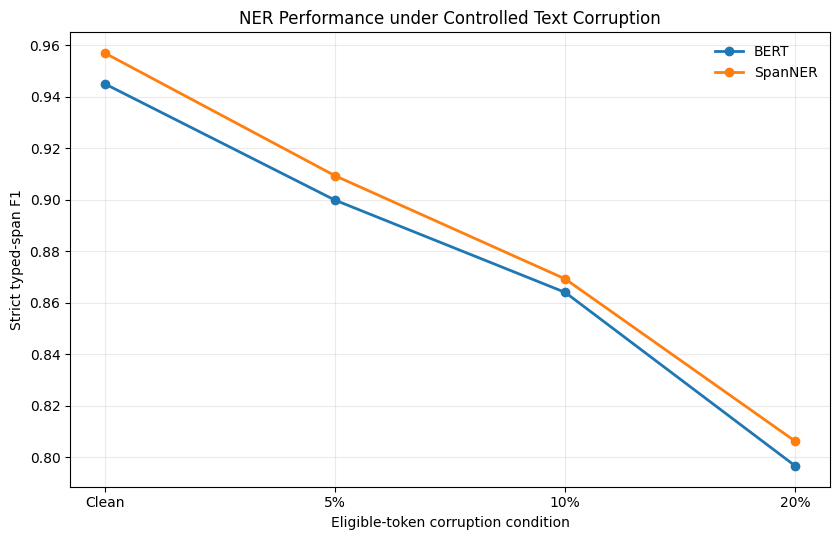

Figure saved: /kaggle/working/07_controlled_noise_robustness/figures/controlled_noise_ner_f1.png


In [20]:
import matplotlib.pyplot as plt


severity_positions = np.arange(
    len(CONDITION_ORDER)
)

severity_labels = [
    CONDITION_LABELS[
        condition
    ]
    for condition
    in CONDITION_ORDER
]


fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)


for model_name in [
    "BERT",
    "SpanNER",
]:

    model_df = (
        robustness_ner_results_df.loc[
            robustness_ner_results_df[
                "Model"
            ].eq(model_name)
        ]
        .sort_values(
            "Condition Order"
        )
    )

    ax.plot(
        severity_positions,
        model_df["F1"].to_numpy(float),
        marker="o",
        linewidth=2,
        label=model_name,
    )


ax.set_xticks(
    severity_positions
)

ax.set_xticklabels(
    severity_labels
)

ax.set_xlabel(
    "Eligible-token corruption condition"
)

ax.set_ylabel(
    "Strict typed-span F1"
)

ax.set_title(
    "NER Performance under Controlled Text Corruption"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    frameon=False
)

fig.tight_layout()


ner_robustness_figure_path = (
    FIGURE_OUTPUT_DIR
    / "controlled_noise_ner_f1.png"
)

fig.savefig(
    ner_robustness_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Figure saved:",
    ner_robustness_figure_path,
)

### Boundary-uncertainty robustness figure

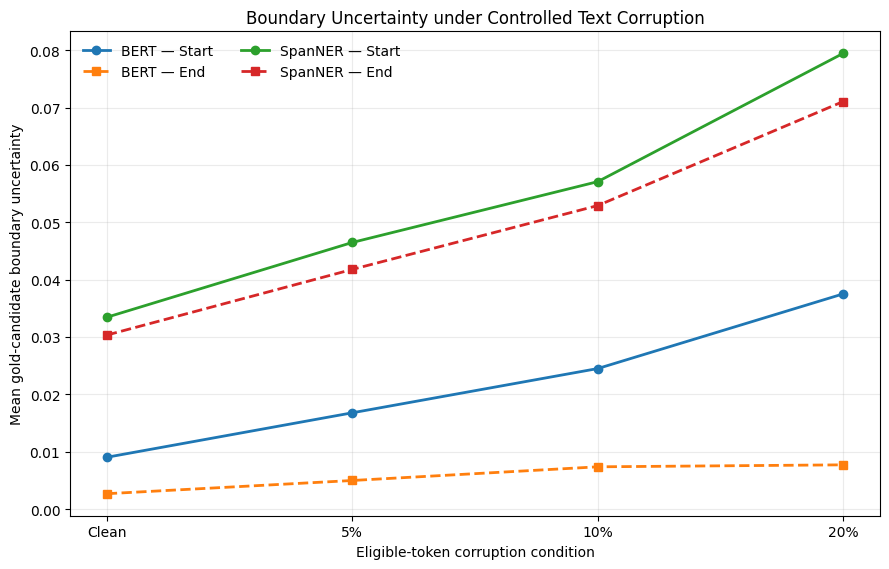

Figure saved: /kaggle/working/07_controlled_noise_robustness/figures/controlled_noise_boundary_uncertainty.png


In [21]:
fig, ax = plt.subplots(
    figsize=(9, 5.8)
)


for model_name in [
    "BERT",
    "SpanNER",
]:

    model_df = (
        robustness_boundary_results_df.loc[
            robustness_boundary_results_df[
                "Model"
            ].eq(model_name)
        ]
        .sort_values(
            "Condition Order"
        )
    )

    ax.plot(
        severity_positions,
        model_df[
            "Mean Gold Start Uncertainty"
        ].to_numpy(float),
        marker="o",
        linewidth=2,
        label=(
            f"{model_name} — Start"
        ),
    )

    ax.plot(
        severity_positions,
        model_df[
            "Mean Gold End Uncertainty"
        ].to_numpy(float),
        marker="s",
        linestyle="--",
        linewidth=2,
        label=(
            f"{model_name} — End"
        ),
    )


ax.set_xticks(
    severity_positions
)

ax.set_xticklabels(
    severity_labels
)

ax.set_xlabel(
    "Eligible-token corruption condition"
)

ax.set_ylabel(
    "Mean gold-candidate boundary uncertainty"
)

ax.set_title(
    "Boundary Uncertainty under Controlled Text Corruption"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    frameon=False,
    ncol=2,
)

fig.tight_layout()


boundary_robustness_figure_path = (
    FIGURE_OUTPUT_DIR
    / "controlled_noise_boundary_uncertainty.png"
)

fig.savefig(
    boundary_robustness_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Figure saved:",
    boundary_robustness_figure_path,
)

### 8.1 Robustness Findings

The controlled-noise experiment produced four main findings.

First, deterministic NER performance deteriorated monotonically with increasing corruption. BERT F1 decreased from 0.9451 on clean text to 0.7966 at 20% corruption, while SpanNER decreased from 0.9571 to 0.8062. SpanNER retained a small performance advantage at every evaluated severity.

Second, corruption also altered the models' uncertainty signals. Mean gold-candidate confidence decreased monotonically for both architectures. Boundary uncertainty generally increased with corruption, with particularly clear increases in start-boundary uncertainty. For BERT, mean start uncertainty increased from 0.0090 on clean text to 0.0375 at 20% corruption. For SpanNER, start uncertainty increased from 0.0334 to 0.0795 and end uncertainty from 0.0303 to 0.0711. The uncertainty signals therefore responded in the expected direction as the input became progressively more difficult.

Third, conformal coverage calibrated on clean data was not preserved under distribution shift. At the primary 90% target, BERT M4 representable-gold sentence coverage decreased from 0.8695 on clean validation text to 0.6745 at 20% corruption. SpanNER M4 decreased from 0.8812 to 0.6677. Fixed alternatives showed similar behaviour, and uncertainty-adaptive M4 did not provide a clear coverage-efficiency advantage.

Finally, the high-coverage analysis reinforced the distinction between coverage retention and efficiency. At the 99% target, SpanNER M4 retained comparatively high empirical coverage under severe corruption, decreasing from 0.9945 to 0.9674, but its mean prediction-set size increased from 90.53 to 106.27 typed candidates. High coverage was therefore retained only with a substantial efficiency cost.

Overall, controlled corruption increased model difficulty and boundary uncertainty while reducing the transferability of clean-calibrated conformal coverage. These results support the use of boundary uncertainty as a diagnostic signal of degradation, but do not show that uncertainty-adaptive conformal scoring is more robust than the fixed alternatives.

## 9. Final Artefacts and Handoff

This notebook completes the controlled-noise robustness stage.

All reported results use the frozen BERT and SpanNER models, frozen temperature parameters, frozen M1–M4 λ configurations and clean-calibrated conformal thresholds established upstream.

The official CoNLL-2003 test set has not been accessed. No model fitting, calibration fitting, λ selection or conformal recalibration has been performed using corrupted validation text.

The resulting artefacts are saved for reporting and reproducibility. Downstream notebooks must treat this robustness analysis as frozen and must not use it to modify the primary conformal specification.

In [22]:
# Restore clean confidence explicitly in the final saved table.
clean_rows = robustness_boundary_results_df[
    "Condition"
].eq("clean")

robustness_boundary_results_df.loc[
    clean_rows,
    "Mean Gold Confidence",
] = (
    1.0
    - robustness_boundary_results_df.loc[
        clean_rows,
        "Mean Gold Base Nonconformity",
    ]
)


robustness_ner_results_df.to_csv(
    RESULTS_OUTPUT_DIR
    / "controlled_noise_ner_results.csv",
    index=False,
)

robustness_boundary_results_df.to_csv(
    RESULTS_OUTPUT_DIR
    / "controlled_noise_boundary_uncertainty.csv",
    index=False,
)

robustness_conformal_results_df.to_csv(
    RESULTS_OUTPUT_DIR
    / "controlled_noise_conformal_results.csv",
    index=False,
)

primary_90_summary_df.to_csv(
    RESULTS_OUTPUT_DIR
    / "primary_90pct_conformal_robustness.csv",
    index=False,
)

secondary_endpoint_df.to_csv(
    RESULTS_OUTPUT_DIR
    / "secondary_95_99pct_conformal_robustness.csv",
    index=False,
)

robustness_sentence_ner_df.to_csv(
    RESULTS_OUTPUT_DIR
    / "sentence_level_ner_robustness.csv",
    index=False,
)

robustness_sentence_conformal_df.to_parquet(
    RESULTS_OUTPUT_DIR
    / "sentence_level_conformal_robustness.parquet",
    index=False,
)


saved_result_paths = [
    RESULTS_OUTPUT_DIR
    / "controlled_noise_ner_results.csv",

    RESULTS_OUTPUT_DIR
    / "controlled_noise_boundary_uncertainty.csv",

    RESULTS_OUTPUT_DIR
    / "controlled_noise_conformal_results.csv",

    RESULTS_OUTPUT_DIR
    / "primary_90pct_conformal_robustness.csv",

    RESULTS_OUTPUT_DIR
    / "secondary_95_99pct_conformal_robustness.csv",

    RESULTS_OUTPUT_DIR
    / "sentence_level_ner_robustness.csv",

    RESULTS_OUTPUT_DIR
    / "sentence_level_conformal_robustness.parquet",
]


missing_saved_results = [
    str(path)
    for path in saved_result_paths
    if not path.exists()
]

if missing_saved_results:
    raise RuntimeError(
        "Some final robustness artefacts were not saved:\n"
        + "\n".join(
            missing_saved_results
        )
    )


print(
    "Final robustness result artefacts saved:",
    len(
        saved_result_paths
    ),
)

for path in saved_result_paths:
    print(
        " -",
        path.name,
    )

Final robustness result artefacts saved: 7
 - controlled_noise_ner_results.csv
 - controlled_noise_boundary_uncertainty.csv
 - controlled_noise_conformal_results.csv
 - primary_90pct_conformal_robustness.csv
 - secondary_95_99pct_conformal_robustness.csv
 - sentence_level_ner_robustness.csv
 - sentence_level_conformal_robustness.parquet


### Final completion record

In [23]:
completion_record = {
    "notebook": (
        "07_controlled_noise_robustness"
    ),
    "status": (
        "CONTROLLED_NOISE_ROBUSTNESS_COMPLETE"
    ),
    "random_seed": int(
        SEED
    ),
    "validation_sentences": int(
        VALIDATION_SENTENCES
    ),
    "validation_tokens": int(
        len(
            bert_validation_token_df
        )
    ),
    "validation_gold_entities": int(
        VALIDATION_GOLD_SPANS
    ),
    "spanner_representable_gold_entities": 2993,
    "noise_conditions": {
        key: float(value)
        for key, value
        in NOISE_CONDITIONS.items()
    },
    "nested_corruption": True,
    "eligible_tokens": int(
        eligible_token_count
    ),
    "changed_tokens": {
        row["Condition"]: int(
            row["Changed Tokens"]
        )
        for _, row
        in noise_realisation_summary_df.iterrows()
    },
    "temperatures": {
        "BERT": float(
            BERT_TEMPERATURE
        ),
        "SpanNER": float(
            SPANNER_TEMPERATURE
        ),
    },
    "primary_conformal_target": 0.90,
    "secondary_conformal_targets": [
        0.95,
        0.99,
    ],
    "clean_reproduction": {
        "BERT_F1": float(
            bert_clean_metrics[
                "F1"
            ]
        ),
        "SpanNER_F1": float(
            spanner_clean_metrics[
                "F1"
            ]
        ),
        "BERT_prediction_mismatches": int(
            bert_prediction_mismatches
        ),
        "passed": True,
    },
    "twenty_percent_noise_f1": {
        "BERT": float(
            robustness_ner_results_df.loc[
                (
                    robustness_ner_results_df[
                        "Model"
                    ].eq("BERT")
                )
                & (
                    robustness_ner_results_df[
                        "Condition"
                    ].eq("high_20")
                ),
                "F1",
            ].iloc[0]
        ),
        "SpanNER": float(
            robustness_ner_results_df.loc[
                (
                    robustness_ner_results_df[
                        "Model"
                    ].eq("SpanNER")
                )
                & (
                    robustness_ner_results_df[
                        "Condition"
                    ].eq("high_20")
                ),
                "F1",
            ].iloc[0]
        ),
    },
    "models_retrained": False,
    "temperatures_refitted": False,
    "lambda_retuning_performed": False,
    "noisy_q_hat_recalibration_performed": False,
    "m5_evaluated": False,
    "official_test_accessed": False,
    "method_development_complete": True,
    "next_notebook": (
        "08_final_locked_conll_test"
    ),
}


completion_record_path = (
    OUTPUT_ROOT
    / "completion_record.json"
)

with completion_record_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        completion_record,
        file,
        indent=2,
    )


print(
    "Notebook 07 status:",
    completion_record[
        "status"
    ],
)

print(
    "Clean reproduction passed:",
    completion_record[
        "clean_reproduction"
    ][
        "passed"
    ],
)

print(
    "Nested corruption:",
    completion_record[
        "nested_corruption"
    ],
)

print(
    "Models retrained:",
    completion_record[
        "models_retrained"
    ],
)

print(
    "Temperatures refitted:",
    completion_record[
        "temperatures_refitted"
    ],
)

print(
    "Lambda retuning performed:",
    completion_record[
        "lambda_retuning_performed"
    ],
)

print(
    "Noisy q-hat recalibration performed:",
    completion_record[
        "noisy_q_hat_recalibration_performed"
    ],
)

print(
    "M5 evaluated:",
    completion_record[
        "m5_evaluated"
    ],
)

print(
    "Official CoNLL test accessed:",
    completion_record[
        "official_test_accessed"
    ],
)

print(
    "Next notebook:",
    completion_record[
        "next_notebook"
    ],
)

print(
    "\nCompletion record saved:",
    completion_record_path,
)

Notebook 07 status: CONTROLLED_NOISE_ROBUSTNESS_COMPLETE
Clean reproduction passed: True
Nested corruption: True
Models retrained: False
Temperatures refitted: False
Lambda retuning performed: False
Noisy q-hat recalibration performed: False
M5 evaluated: False
Official CoNLL test accessed: False
Next notebook: 08_final_locked_conll_test

Completion record saved: /kaggle/working/07_controlled_noise_robustness/completion_record.json
